# Clinical-trial negative efficacy classifier

Google Colab notebook for classifying a single clinical-trial termination sentence into:

- **1 = negative efficacy / futility / endpoints not met**
- **0 = all other reasons**

This version focuses on:
- TF-IDF + Logistic Regression baseline
- **DeBERTa-v3-base**
- **SetFit**
- comparison against the public Open Targets / Razuvayevskaya proxy model and the group-presentation benchmarks
- calibrated probabilities, threshold tuning, and conformal prediction sets


In [29]:
!pip -q install -U "transformers>=4.46,<4.49" accelerate datasets scikit-learn joblib openpyxl setfit sentence-transformers

In [30]:
import os
import gc
import json
import math
import random
import shutil
import warnings
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.special import softmax
from sklearn.calibration import calibration_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import FeatureUnion
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

from datasets import Dataset as HFDataset
from setfit import SetFitModel, SetFitTrainer

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


In [31]:
SHEET_NAME = "ST1"
HEADER_ROW = 2
TEXT_COL = "Reasons for termination"
LABEL_COLS = ["Reason1", "Reason2", "Reason3"]
STATUS_COL = "Status"
CATEGORY_COL = "Category"

POSITIVE_REASON_LABELS = {
    "Insufficient Efficacy",
    "Futility",
    "Unmet endpoint",
}

RELAXED_EXTRA_POSITIVE_LABELS = set([
    # Example if you later want it:
    # "Based on data in this study"
])

DROP_CONFLICTING_DUPLICATE_TEXTS = True
DROP_EMPTY_TEXTS = True

TEST_SIZE = 0.20
VAL_SIZE = 0.10
CAL_SIZE = 0.10

MAX_LEN = 96
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
NUM_EPOCHS = 7
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

SETFIT_NUM_EPOCHS = 1
SETFIT_NUM_ITERATIONS = 20
SETFIT_BATCH_SIZE = 64
SETFIT_LEARNING_RATE = 2e-5

MODELS_TO_RUN = {
    "logreg": True,
    "distilbert": True,
    "biomedbert": True,
    "deberta_v3": True,
    "setfit": True,
}

HF_MODELS = {
    "distilbert": "distilbert/distilbert-base-uncased",
    "biomedbert": "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext",
    "deberta_v3": "microsoft/deberta-v3-base",
    "setfit": "sentence-transformers/paraphrase-mpnet-base-v2",

}


EXPORT_DIR = Path("/content/negative_efficacy_export") if IN_COLAB else Path("./negative_efficacy_export")
LOCAL_WORKBOOK_PATH = None
LOGREG_C_GRID = [2.0, 4.0]


In [32]:
def resolve_input_path(local_path=None):
    if local_path:
        p = Path(local_path)
        if p.exists():
            return p

    candidates = [
        Path("/content/41588_2024_1854_MOESM3_ESM.xlsx"),
        Path("./41588_2024_1854_MOESM3_ESM.xlsx"),
        Path("/mnt/data/41588_2024_1854_MOESM3_ESM.xlsx"),
    ]
    for p in candidates:
        if p.exists():
            return p

    if IN_COLAB:
        print("Upload the workbook now...")
        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError("No workbook uploaded.")
        return Path(next(iter(uploaded.keys())))

    raise FileNotFoundError("Workbook not found. Set LOCAL_WORKBOOK_PATH or upload the file.")

WORKBOOK_PATH = resolve_input_path(LOCAL_WORKBOOK_PATH)
print("Using workbook:", WORKBOOK_PATH)

raw_df = pd.read_excel(WORKBOOK_PATH, sheet_name=SHEET_NAME, header=HEADER_ROW)
display(raw_df.head())
print(raw_df.shape)
print(raw_df.columns.tolist())

Using workbook: /content/41588_2024_1854_MOESM3_ESM.xlsx


,Reason1,Reason2,Reason3,Concat,Count,Terminated Trial,Phase,Min Phase,NCT ID,Status,Category,Reasons for termination
0,Administrative reasons,Business decision,NaN,|Administrative reasons|Business decision||,2,NCT00757/NCT00757757.xml-32-,Phase 1/Phase 2,1,NCT00757757,Terminated,Suspicious,Novartis decided to terminate based on strateg...
1,Administrative reasons,Business decision,NaN,|Administrative reasons|Business decision||,2,NCT00408/NCT00408148.xml-47-,Phase 3,3,NCT00408148,Terminated,Suspicious,Company decision has been taken in light of re...
2,Administrative reasons,Business decision,NaN,|Administrative reasons|Business decision||,2,NCT00577/NCT00577148.xml-33-,Phase 3,3,NCT00577148,Terminated,Suspicious,Company decision taken in light of demands by ...
3,Administrative reasons,Business decision,NaN,|Administrative reasons|Business decision||,2,NCT00690/NCT00690456.xml-39-,Phase 3,3,NCT00690456,Terminated,Suspicious,Company decision taken in light of demands by ...
4,Administrative reasons,Business decision,NaN,|Administrative reasons|Business decision||,2,NCT00678/NCT00678483.xml-44-,Phase 3,3,NCT00678483,Terminated,Suspicious,Company decision taken in light of demands by ...


(3124, 12)
['Reason1', 'Reason2', 'Reason3', 'Concat', 'Count', 'Terminated Trial', 'Phase', 'Min Phase', 'NCT ID', 'Status', 'Category', 'Reasons for termination']


In [33]:
def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace("&amp;", "&")
    text = re.sub(r"\s+", " ", text.strip().lower())
    return text

def derive_binary_label(row, positive_labels):
    labels = {row.get(col) for col in LABEL_COLS if pd.notna(row.get(col))}
    return int(any(label in positive_labels for label in labels))

LOW_INFO_PATTERNS = [
    r"^see detailed description\.?$",
    r"^see termination reason in detailed description\.?$",
    r"^please see detailed description(?: below)? for termination reason\.?$",
]

def is_low_information_text(text_norm):
    return any(re.match(pat, text_norm) for pat in LOW_INFO_PATTERNS)

def build_binary_dataset(df, positive_labels, drop_conflicting_duplicate_texts=True):
    required = set(LABEL_COLS + [TEXT_COL, STATUS_COL, CATEGORY_COL])
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing expected columns: {sorted(missing)}")

    work = df.copy()

    if DROP_EMPTY_TEXTS:
        work = work.loc[work[TEXT_COL].notna()].copy()
        work = work.loc[work[TEXT_COL].astype(str).str.strip().ne("")].copy()

    work["text"] = work[TEXT_COL].astype(str)
    work["text_norm"] = work["text"].map(normalize_text)
    work["label"] = work.apply(lambda row: derive_binary_label(row, positive_labels), axis=1).astype(int)
    work["low_information_text"] = work["text_norm"].map(is_low_information_text)

    work["reason_labels"] = work[LABEL_COLS].apply(
        lambda row: sorted({v for v in row.values.tolist() if pd.notna(v)}),
        axis=1,
    )

    label_nunique_by_text = work.groupby("text_norm")["label"].nunique()
    conflict_texts = set(label_nunique_by_text[label_nunique_by_text > 1].index)
    work["text_conflict"] = work["text_norm"].isin(conflict_texts)

    if drop_conflicting_duplicate_texts:
        work = work.loc[~work["text_conflict"]].copy()

    work = work.reset_index(drop=True)
    return work, conflict_texts

binary_df, conflict_texts = build_binary_dataset(
    raw_df,
    POSITIVE_REASON_LABELS | RELAXED_EXTRA_POSITIVE_LABELS,
    drop_conflicting_duplicate_texts=DROP_CONFLICTING_DUPLICATE_TEXTS,
)

print("Rows after preprocessing:", len(binary_df))
print("Positive rows:", int(binary_df["label"].sum()))
print("Positive rate:", round(float(binary_df["label"].mean()), 4))
print("Conflicting normalized texts removed:", len(conflict_texts))
print("Low-information rows flagged:", int(binary_df["low_information_text"].sum()))
display(binary_df[[TEXT_COL, "label", "reason_labels", "low_information_text"]].head(10))

Rows after preprocessing: 3022
Positive rows: 239
Positive rate: 0.0791
Conflicting normalized texts removed: 10
Low-information rows flagged: 0


,Reasons for termination,label,reason_labels,low_information_text
0,Novartis decided to terminate based on strateg...,0,"[Administrative reasons, Business decision]",False
1,Company decision has been taken in light of re...,0,"[Administrative reasons, Business decision]",False
2,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
3,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
4,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
5,Company decision has been taken in light of re...,0,"[Administrative reasons, Business decision]",False
6,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
7,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
8,Company decision taken in light of demands by ...,0,"[Administrative reasons, Business decision]",False
9,Company decision has been taken in light of re...,0,"[Administrative reasons, Business decision]",False


In [34]:
print("Category distribution")
display(binary_df[CATEGORY_COL].value_counts(dropna=False).to_frame("count"))

print("Status distribution")
display(binary_df[STATUS_COL].value_counts(dropna=False).to_frame("count"))

print("Positive examples")
display(
    binary_df.loc[binary_df["label"] == 1, [TEXT_COL, "reason_labels"]]
    .sample(min(12, int(binary_df["label"].sum())), random_state=SEED)
)

print("Conflicting texts removed (sample)")
for x in list(sorted(conflict_texts))[:10]:
    print("-", x)

Category distribution


,count
Category,
Neutral,1660
Suspicious,623
Negative,304
Misuse,236
Safety,182
Positive,17


Status distribution


,count
Status,
Terminated,2257
Withdrawn,457
Suspended,308


Positive examples


,Reasons for termination,reason_labels
860,The study was terminated on the basis of futil...,"[Futility, Insufficient Efficacy]"
99,Study was terminated due to insufficient clini...,"[Another study, Insufficient Efficacy]"
966,Efficacy seen in the solid tumour patient popu...,[Insufficient Efficacy]
982,Primary efficacy analysis at Week 24 did not d...,[Insufficient Efficacy]
977,lack of efficacy,[Insufficient Efficacy]
1045,Lack of Efficacy.,[Insufficient Efficacy]
1073,Study was stopped after pre-definied interim a...,[Insufficient Efficacy]
959,&quot;Tapering doses&quot; protocol arm was no...,[Insufficient Efficacy]
102,Negative efficacy results of the MAESTRO-01 study,"[Another study, Insufficient Efficacy]"
1015,The planned enrollment was 130 patients and th...,[Insufficient Efficacy]


Conflicting texts removed (sample)
- emd serono voluntarily decided to terminate this trial after observing increased ms disease activity in trial 28063 atams [please refer to atams]
- enrollment suspended based upon interim analysis; subjects allowed to stay on study until disease progression.
- please see detailed description below for termination reason.
- please see detailed description for termination reason.
- see detailed description
- see detailed description for termination reason
- see detailed description for termination reason.
- see detailed description.
- see termination reason in detailed description
- see termination reason in detailed description.


In [7]:
def make_group_splits(df, group_col="text_norm", label_col="label", test_size=0.2, val_size=0.1, cal_size=0.1, seed=42):
    if test_size + val_size + cal_size >= 1.0:
        raise ValueError("test_size + val_size + cal_size must be < 1.0")

    groups = df[[group_col, label_col]].drop_duplicates().reset_index(drop=True)

    train_val_cal_groups, test_groups = train_test_split(
        groups,
        test_size=test_size,
        random_state=seed,
        stratify=groups[label_col],
    )

    remaining_after_test = 1.0 - test_size
    val_rel = val_size / remaining_after_test

    train_cal_groups, val_groups = train_test_split(
        train_val_cal_groups,
        test_size=val_rel,
        random_state=seed,
        stratify=train_val_cal_groups[label_col],
    )

    remaining_after_test_val = remaining_after_test - val_size
    cal_rel = cal_size / remaining_after_test_val

    train_groups, cal_groups = train_test_split(
        train_cal_groups,
        test_size=cal_rel,
        random_state=seed,
        stratify=train_cal_groups[label_col],
    )

    split_map = {}
    for split_name, split_part in {
        "train": train_groups,
        "val": val_groups,
        "cal": cal_groups,
        "test": test_groups,
    }.items():
        for key in split_part[group_col]:
            split_map[key] = split_name

    out = df.copy()
    out["split"] = out[group_col].map(split_map)
    assert out["split"].isna().sum() == 0
    return out

split_df = make_group_splits(
    binary_df,
    group_col="text_norm",
    label_col="label",
    test_size=TEST_SIZE,
    val_size=VAL_SIZE,
    cal_size=CAL_SIZE,
    seed=SEED,
)

for split_name in ["train", "val", "cal", "test"]:
    sub = split_df.loc[split_df["split"] == split_name]
    print(
        split_name,
        {
            "rows": len(sub),
            "positive_rows": int(sub["label"].sum()),
            "positive_rate": round(float(sub["label"].mean()), 4),
            "unique_groups": sub["text_norm"].nunique(),
        },
    )

train_df = split_df.loc[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df.loc[split_df["split"] == "val"].reset_index(drop=True)
cal_df = split_df.loc[split_df["split"] == "cal"].reset_index(drop=True)
test_df = split_df.loc[split_df["split"] == "test"].reset_index(drop=True)

train {'rows': 1748, 'positive_rows': 137, 'positive_rate': 0.0784, 'unique_groups': 1446}
val {'rows': 290, 'positive_rows': 22, 'positive_rate': 0.0759, 'unique_groups': 242}
cal {'rows': 320, 'positive_rows': 34, 'positive_rate': 0.1062, 'unique_groups': 242}
test {'rows': 664, 'positive_rows': 46, 'positive_rate': 0.0693, 'unique_groups': 483}


In [8]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins) - 1
    bin_ids = np.clip(bin_ids, 0, n_bins - 1)

    ece = 0.0
    for i in range(n_bins):
        mask = bin_ids == i
        if not np.any(mask):
            continue
        ece += np.abs(y_true[mask].mean() - y_prob[mask].mean()) * mask.mean()
    return float(ece)

def best_f1_threshold(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    thresholds = np.unique(np.concatenate([np.linspace(0.01, 0.99, 199), y_prob]))
    best_t = 0.5
    best_score = -1.0
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        score = f1_score(y_true, preds, zero_division=0)
        if score > best_score:
            best_score = score
            best_t = float(t)
    return best_t, float(best_score)

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "average_precision": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "ece_10": expected_calibration_error(y_true, y_prob, n_bins=10),
        "threshold": threshold,
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        out["roc_auc"] = np.nan
    return out

def plot_model_diagnostics(y_true, y_prob, threshold=0.5, title_prefix=""):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = compute_binary_metrics(y_true, y_prob, threshold=threshold)
    cm = confusion_matrix(y_true, y_pred)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

    title_fs = 17
    label_fs = 13
    tick_fs = 12
    legend_fs = 11
    annot_fs = 14

    fig, axes = plt.subplots(2, 2, figsize=(14, 11), dpi=150)
    axes = axes.ravel()

    header = f"{title_prefix.strip()} diagnostics" if title_prefix else "Model diagnostics"
    fig.suptitle(header, fontsize=20, fontweight="bold", y=1.02)

    # ROC
    try:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        roc_auc = roc_auc_score(y_true, y_prob)
        axes[0].plot(fpr, tpr, linewidth=2.5, label=f"AUC = {roc_auc:.3f}")
        axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, alpha=0.8)
        axes[0].legend(loc="lower right", frameon=True, fontsize=legend_fs)
        axes[0].set_title("ROC curve", fontsize=title_fs)
        axes[0].set_xlabel("False positive rate", fontsize=label_fs)
        axes[0].set_ylabel("True positive rate", fontsize=label_fs)
        axes[0].set_xlim(0, 1)
        axes[0].set_ylim(0, 1.02)
        axes[0].grid(True, alpha=0.25)
    except Exception:
        axes[0].text(0.5, 0.5, "ROC unavailable", ha="center", va="center", fontsize=label_fs)
        axes[0].set_title("ROC curve", fontsize=title_fs)
        axes[0].set_axis_off()

    # Precision-recall
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    prevalence = float(np.mean(y_true)) if len(y_true) else 0.0
    axes[1].plot(rec, prec, linewidth=2.5, label=f"AP = {ap:.3f}")
    axes[1].hlines(
        prevalence,
        0,
        1,
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        label=f"Prevalence = {prevalence:.3f}",
    )
    axes[1].legend(loc="lower left", frameon=True, fontsize=legend_fs)
    axes[1].set_title("Precision-recall curve", fontsize=title_fs)
    axes[1].set_xlabel("Recall", fontsize=label_fs)
    axes[1].set_ylabel("Precision", fontsize=label_fs)
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.02)
    axes[1].grid(True, alpha=0.25)

    # Calibration / reliability
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10, strategy="uniform")
    axes[2].plot(mean_pred, frac_pos, marker="o", linewidth=2.3, markersize=7, label="Observed")
    axes[2].plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, alpha=0.8, label="Ideal")
    axes[2].legend(loc="upper left", frameon=True, fontsize=legend_fs)
    axes[2].set_title(
        f"Reliability diagram (ECE={metrics['ece_10']:.3f}, Brier={metrics['brier']:.3f})",
        fontsize=title_fs,
    )
    axes[2].set_xlabel("Mean predicted probability", fontsize=label_fs)
    axes[2].set_ylabel("Observed positive rate", fontsize=label_fs)
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1.02)
    axes[2].grid(True, alpha=0.25)

    # Confusion matrix
    im = axes[3].imshow(cm_norm, cmap="Blues", vmin=0.0, vmax=1.0)
    axes[3].set_title(
        f"Confusion matrix @ threshold = {threshold:.3f}\n"
        f"Acc={metrics['accuracy']:.3f} | F1={metrics['f1']:.3f} | "
        f"P={metrics['precision']:.3f} | R={metrics['recall']:.3f}",
        fontsize=title_fs,
    )
    axes[3].set_xlabel("Predicted label", fontsize=label_fs)
    axes[3].set_ylabel("True label", fontsize=label_fs)
    axes[3].set_xticks([0, 1], labels=["Other", "Neg efficacy"])
    axes[3].set_yticks([0, 1], labels=["Other", "Neg efficacy"])
    axes[3].set_aspect("equal")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm_norm[i, j]
            text_color = "white" if val >= 0.5 else "black"
            axes[3].text(
                j,
                i,
                f"{cm[i, j]:,}\n({val:.1%})",
                ha="center",
                va="center",
                fontsize=annot_fs,
                fontweight="bold",
                color=text_color,
            )

    cbar = fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=tick_fs)
    cbar.set_label("Row-normalised proportion", fontsize=label_fs)

    for ax in axes:
        ax.tick_params(axis="both", labelsize=tick_fs)

    plt.tight_layout()
    plt.show()

class SigmoidScoreCalibrator:
    def __init__(self):
        self.model = LogisticRegression(solver="lbfgs")

    def fit(self, scores, y):
        self.model.fit(np.asarray(scores).reshape(-1, 1), np.asarray(y).astype(int))
        return self

    def predict_proba(self, scores):
        return self.model.predict_proba(np.asarray(scores).reshape(-1, 1))[:, 1]

def fit_split_conformal(prob_pos, y_true, alpha=0.10):
    prob_pos = np.asarray(prob_pos).astype(float)
    y_true = np.asarray(y_true).astype(int)
    true_prob = np.where(y_true == 1, prob_pos, 1.0 - prob_pos)
    nonconformity = 1.0 - true_prob
    n = len(nonconformity)
    q = min(math.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    try:
        qhat = np.quantile(nonconformity, q, method="higher")
    except TypeError:
        qhat = np.quantile(nonconformity, q, interpolation="higher")
    return float(qhat)

def conformal_prediction_sets(prob_pos, qhat):
    prob_pos = np.asarray(prob_pos).astype(float)
    out = []
    for p1 in prob_pos:
        p0 = 1.0 - p1
        pred_set = []
        if 1.0 - p0 <= qhat:
            pred_set.append(0)
        if 1.0 - p1 <= qhat:
            pred_set.append(1)
        out.append(pred_set)
    return out

In [9]:
RESULTS = {}
ARTIFACTS = {}

,0
accuracy,0.962349
precision,0.744186
recall,0.695652
f1,0.719101
average_precision,0.832117
brier,0.030301
ece_10,0.02013
threshold,0.648485
roc_auc,0.978683
model_name,TFIDF+LogReg


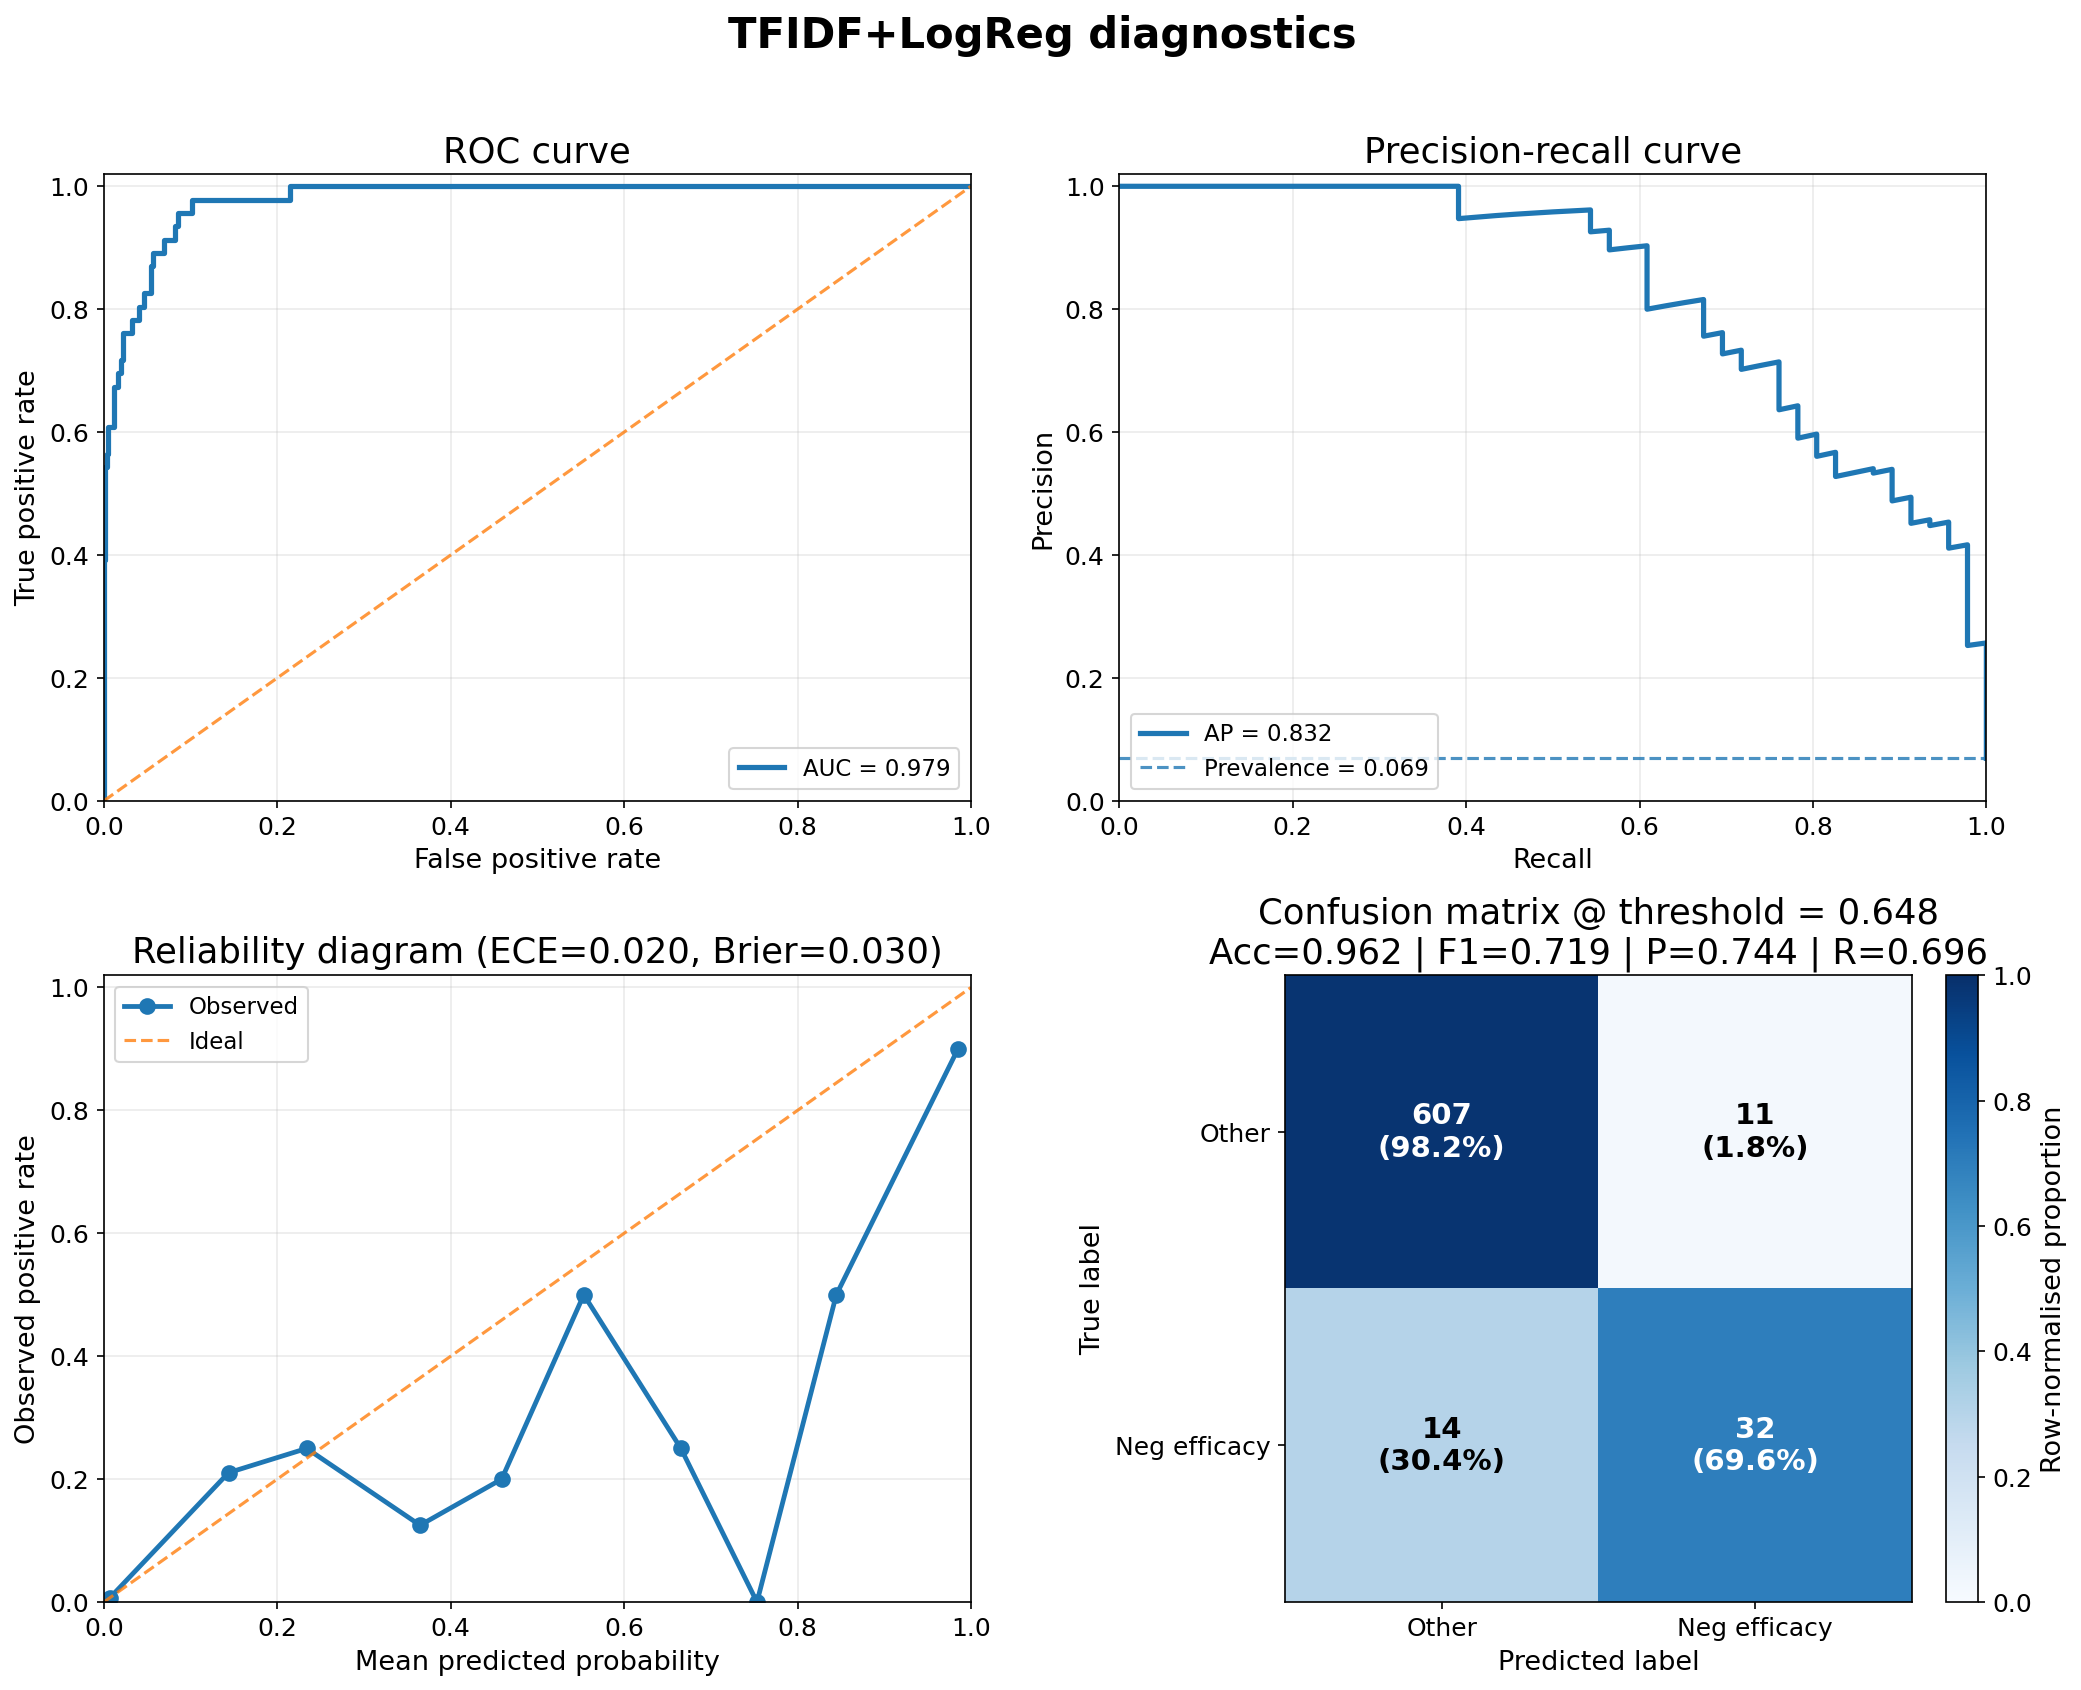

In [10]:
def train_logistic_baseline(train_df, val_df, cal_df, test_df):
    vectorizer = FeatureUnion([
        ("word", TfidfVectorizer(
            lowercase=True,
            strip_accents="unicode",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True,
        )),
        ("char", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
        )),
    ])

    X_train = vectorizer.fit_transform(train_df["text"])
    X_val = vectorizer.transform(val_df["text"])
    X_cal = vectorizer.transform(cal_df["text"])
    X_test = vectorizer.transform(test_df["text"])

    y_train = train_df["label"].to_numpy()
    y_val = val_df["label"].to_numpy()
    y_cal = cal_df["label"].to_numpy()
    y_test = test_df["label"].to_numpy()

    best = None
    for c in LOGREG_C_GRID:
        clf = LogisticRegression(C=c, class_weight="balanced", max_iter=4000, solver="liblinear")
        clf.fit(X_train, y_train)
        val_prob = clf.predict_proba(X_val)[:, 1]
        ap = average_precision_score(y_val, val_prob)
        if best is None or ap > best["val_ap"]:
            best = {"C": c, "clf": clf, "val_ap": ap}

    clf = best["clf"]
    cal_scores = clf.decision_function(X_cal)
    calibrator = SigmoidScoreCalibrator().fit(cal_scores, y_cal)

    val_prob = calibrator.predict_proba(clf.decision_function(X_val))
    test_prob = calibrator.predict_proba(clf.decision_function(X_test))
    threshold, _ = best_f1_threshold(y_val, val_prob)
    metrics = compute_binary_metrics(y_test, test_prob, threshold=threshold)

    cal_prob = calibrator.predict_proba(cal_scores)
    qhat = fit_split_conformal(cal_prob, y_cal, alpha=0.10)

    artifacts = {
        "type": "logreg",
        "vectorizer": vectorizer,
        "model": clf,
        "calibrator": calibrator,
        "threshold": threshold,
        "qhat": qhat,
        "positive_reason_labels": sorted(POSITIVE_REASON_LABELS | RELAXED_EXTRA_POSITIVE_LABELS),
    }
    aux = {
        "test_prob": test_prob,
        "y_test": y_test,
        "best_C": best["C"],
    }
    return metrics, artifacts, aux

if MODELS_TO_RUN["logreg"]:
    metrics, artifacts, aux = train_logistic_baseline(train_df, val_df, cal_df, test_df)
    RESULTS["logreg"] = metrics | {"model_name": "TFIDF+LogReg", "best_C": aux["best_C"]}
    ARTIFACTS["logreg"] = artifacts
    display(pd.DataFrame([RESULTS["logreg"]]).T)
    plot_model_diagnostics(aux["y_test"], aux["test_prob"], threshold=artifacts["threshold"], title_prefix="TFIDF+LogReg")

In [11]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=96):
        self.texts = list(texts)
        self.labels = None if labels is None else list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        weight = None if self.class_weights is None else self.class_weights.to(logits.device)
        loss = nn.CrossEntropyLoss(weight=weight)(logits, labels)
        return (loss, outputs) if return_outputs else loss

def hf_compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = softmax(logits, axis=1)[:, 1]
    preds = (probs >= 0.5).astype(int)
    out = {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "average_precision": average_precision_score(labels, probs),
    }
    try:
        out["roc_auc"] = roc_auc_score(labels, probs)
    except Exception:
        out["roc_auc"] = np.nan
    return out

def predict_logits(model, tokenizer, texts, batch_size=32, max_length=96):
    ds = TextDataset(texts, labels=None, tokenizer=tokenizer, max_length=max_length)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    model.eval()
    all_logits = []
    with torch.no_grad():
        for batch in dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            all_logits.append(outputs.logits.detach().cpu().numpy())
    return np.vstack(all_logits)

def fit_temperature(logits, y_true, max_iter=50):
    logits_t = torch.tensor(logits, dtype=torch.float32)
    labels_t = torch.tensor(np.asarray(y_true).astype(int), dtype=torch.long)
    temperature = nn.Parameter(torch.ones(1))
    optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=max_iter)
    nll = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        loss = nll(logits_t / temperature.clamp(min=1e-3), labels_t)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(temperature.detach().clamp(min=1e-3).cpu().item())

def apply_temperature(logits, temperature):
    return softmax(logits / float(temperature), axis=1)[:, 1]

In [12]:
def train_transformer_model(model_key, model_name, train_df, val_df, cal_df, test_df):
    seed_everything(SEED)
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.to(DEVICE)

    train_ds = TextDataset(train_df["text"], train_df["label"], tokenizer, max_length=MAX_LEN)
    val_ds = TextDataset(val_df["text"], val_df["label"], tokenizer, max_length=MAX_LEN)

    class_counts = train_df["label"].value_counts().sort_index()
    total = int(class_counts.sum())
    class_weights = torch.tensor(
        [total / max(int(class_counts.get(0, 1)), 1), total / max(int(class_counts.get(1, 1)), 1)],
        dtype=torch.float32,
    )

    output_dir = Path("./trainer_outputs") / model_key
    output_dir.mkdir(parents=True, exist_ok=True)

    args = TrainingArguments(
        output_dir=str(output_dir),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="eval_average_precision",
        greater_is_better=True,
        report_to="none",
        seed=SEED,
        fp16=torch.cuda.is_available(),
        dataloader_pin_memory=torch.cuda.is_available(),
    )

    trainer = WeightedTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        class_weights=class_weights,
        compute_metrics=hf_compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()

    val_logits = predict_logits(model, tokenizer, val_df["text"].tolist(), batch_size=EVAL_BATCH_SIZE, max_length=MAX_LEN)
    cal_logits = predict_logits(model, tokenizer, cal_df["text"].tolist(), batch_size=EVAL_BATCH_SIZE, max_length=MAX_LEN)
    test_logits = predict_logits(model, tokenizer, test_df["text"].tolist(), batch_size=EVAL_BATCH_SIZE, max_length=MAX_LEN)

    temperature = fit_temperature(cal_logits, cal_df["label"].to_numpy())
    val_prob = apply_temperature(val_logits, temperature)
    cal_prob = apply_temperature(cal_logits, temperature)
    test_prob = apply_temperature(test_logits, temperature)

    threshold, _ = best_f1_threshold(val_df["label"].to_numpy(), val_prob)
    metrics = compute_binary_metrics(test_df["label"].to_numpy(), test_prob, threshold=threshold)
    qhat = fit_split_conformal(cal_prob, cal_df["label"].to_numpy(), alpha=0.10)

    artifacts = {
        "type": "transformer",
        "model_key": model_key,
        "model_name": model_name,
        "tokenizer": tokenizer,
        "model": model,
        "temperature": temperature,
        "threshold": threshold,
        "qhat": qhat,
        "positive_reason_labels": sorted(POSITIVE_REASON_LABELS | RELAXED_EXTRA_POSITIVE_LABELS),
    }
    aux = {
        "test_prob": test_prob,
        "y_test": test_df["label"].to_numpy(),
    }
    return metrics, artifacts, aux

def _to_hf_dataset(df):
    return HFDataset.from_pandas(
        df[["text", "label"]].reset_index(drop=True),
        preserve_index=False,
    )

def _as_numpy(x):
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    return np.asarray(x)

def _prob_to_logit(prob, eps=1e-6):
    prob = np.clip(np.asarray(prob).astype(float), eps, 1.0 - eps)
    return np.log(prob / (1.0 - prob))

def train_setfit_model(model_key, model_name, train_df, val_df, cal_df, test_df):
    seed_everything(SEED)

    train_ds = _to_hf_dataset(train_df)
    val_ds = _to_hf_dataset(val_df)

    model = SetFitModel.from_pretrained(model_name)
    try:
        model.to(DEVICE)
    except Exception:
        pass

    trainer = SetFitTrainer(
        model=model,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        metric="f1",
        metric_kwargs={"average": "binary"},
        batch_size=SETFIT_BATCH_SIZE,
        num_epochs=SETFIT_NUM_EPOCHS,
        num_iterations=SETFIT_NUM_ITERATIONS,
        learning_rate=SETFIT_LEARNING_RATE,
        column_mapping={"text": "text", "label": "label"},
        use_amp=torch.cuda.is_available(),
    )
    trainer.train()

    val_prob_raw = _as_numpy(model.predict_proba(val_df["text"].tolist()))[:, 1]
    cal_prob_raw = _as_numpy(model.predict_proba(cal_df["text"].tolist()))[:, 1]
    test_prob_raw = _as_numpy(model.predict_proba(test_df["text"].tolist()))[:, 1]

    calibrator = SigmoidScoreCalibrator().fit(_prob_to_logit(cal_prob_raw), cal_df["label"].to_numpy())
    val_prob = calibrator.predict_proba(_prob_to_logit(val_prob_raw))
    cal_prob = calibrator.predict_proba(_prob_to_logit(cal_prob_raw))
    test_prob = calibrator.predict_proba(_prob_to_logit(test_prob_raw))

    threshold, _ = best_f1_threshold(val_df["label"].to_numpy(), val_prob)
    metrics = compute_binary_metrics(test_df["label"].to_numpy(), test_prob, threshold=threshold)
    qhat = fit_split_conformal(cal_prob, cal_df["label"].to_numpy(), alpha=0.10)

    artifacts = {
        "type": "setfit",
        "model_key": model_key,
        "model_name": model_name,
        "model": model,
        "calibrator": calibrator,
        "threshold": threshold,
        "qhat": qhat,
        "positive_reason_labels": sorted(POSITIVE_REASON_LABELS | RELAXED_EXTRA_POSITIVE_LABELS),
    }
    aux = {
        "test_prob": test_prob,
        "test_prob_raw": test_prob_raw,
        "y_test": test_df["label"].to_numpy(),
    }
    return metrics, artifacts, aux


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Average Precision,Roc Auc
1,0.488800,0.253586,0.962069,0.866667,0.590909,0.702703,0.717349,0.905444
2,0.264500,0.225546,0.944828,0.615385,0.727273,0.666667,0.778130,0.909854
3,0.144800,0.288178,0.937931,0.566667,0.772727,0.653846,0.785495,0.917910
4,0.087800,0.262806,0.958621,0.750000,0.681818,0.714286,0.761887,0.907564
5,0.048200,0.291002,0.962069,0.789474,0.681818,0.731707,0.772580,0.907819


,0
accuracy,0.960843
precision,0.794118
recall,0.586957
f1,0.675
average_precision,0.79897
brier,0.038216
ece_10,0.033214
threshold,0.985051
roc_auc,0.973829
model_name,distilbert/distilbert-base-uncased


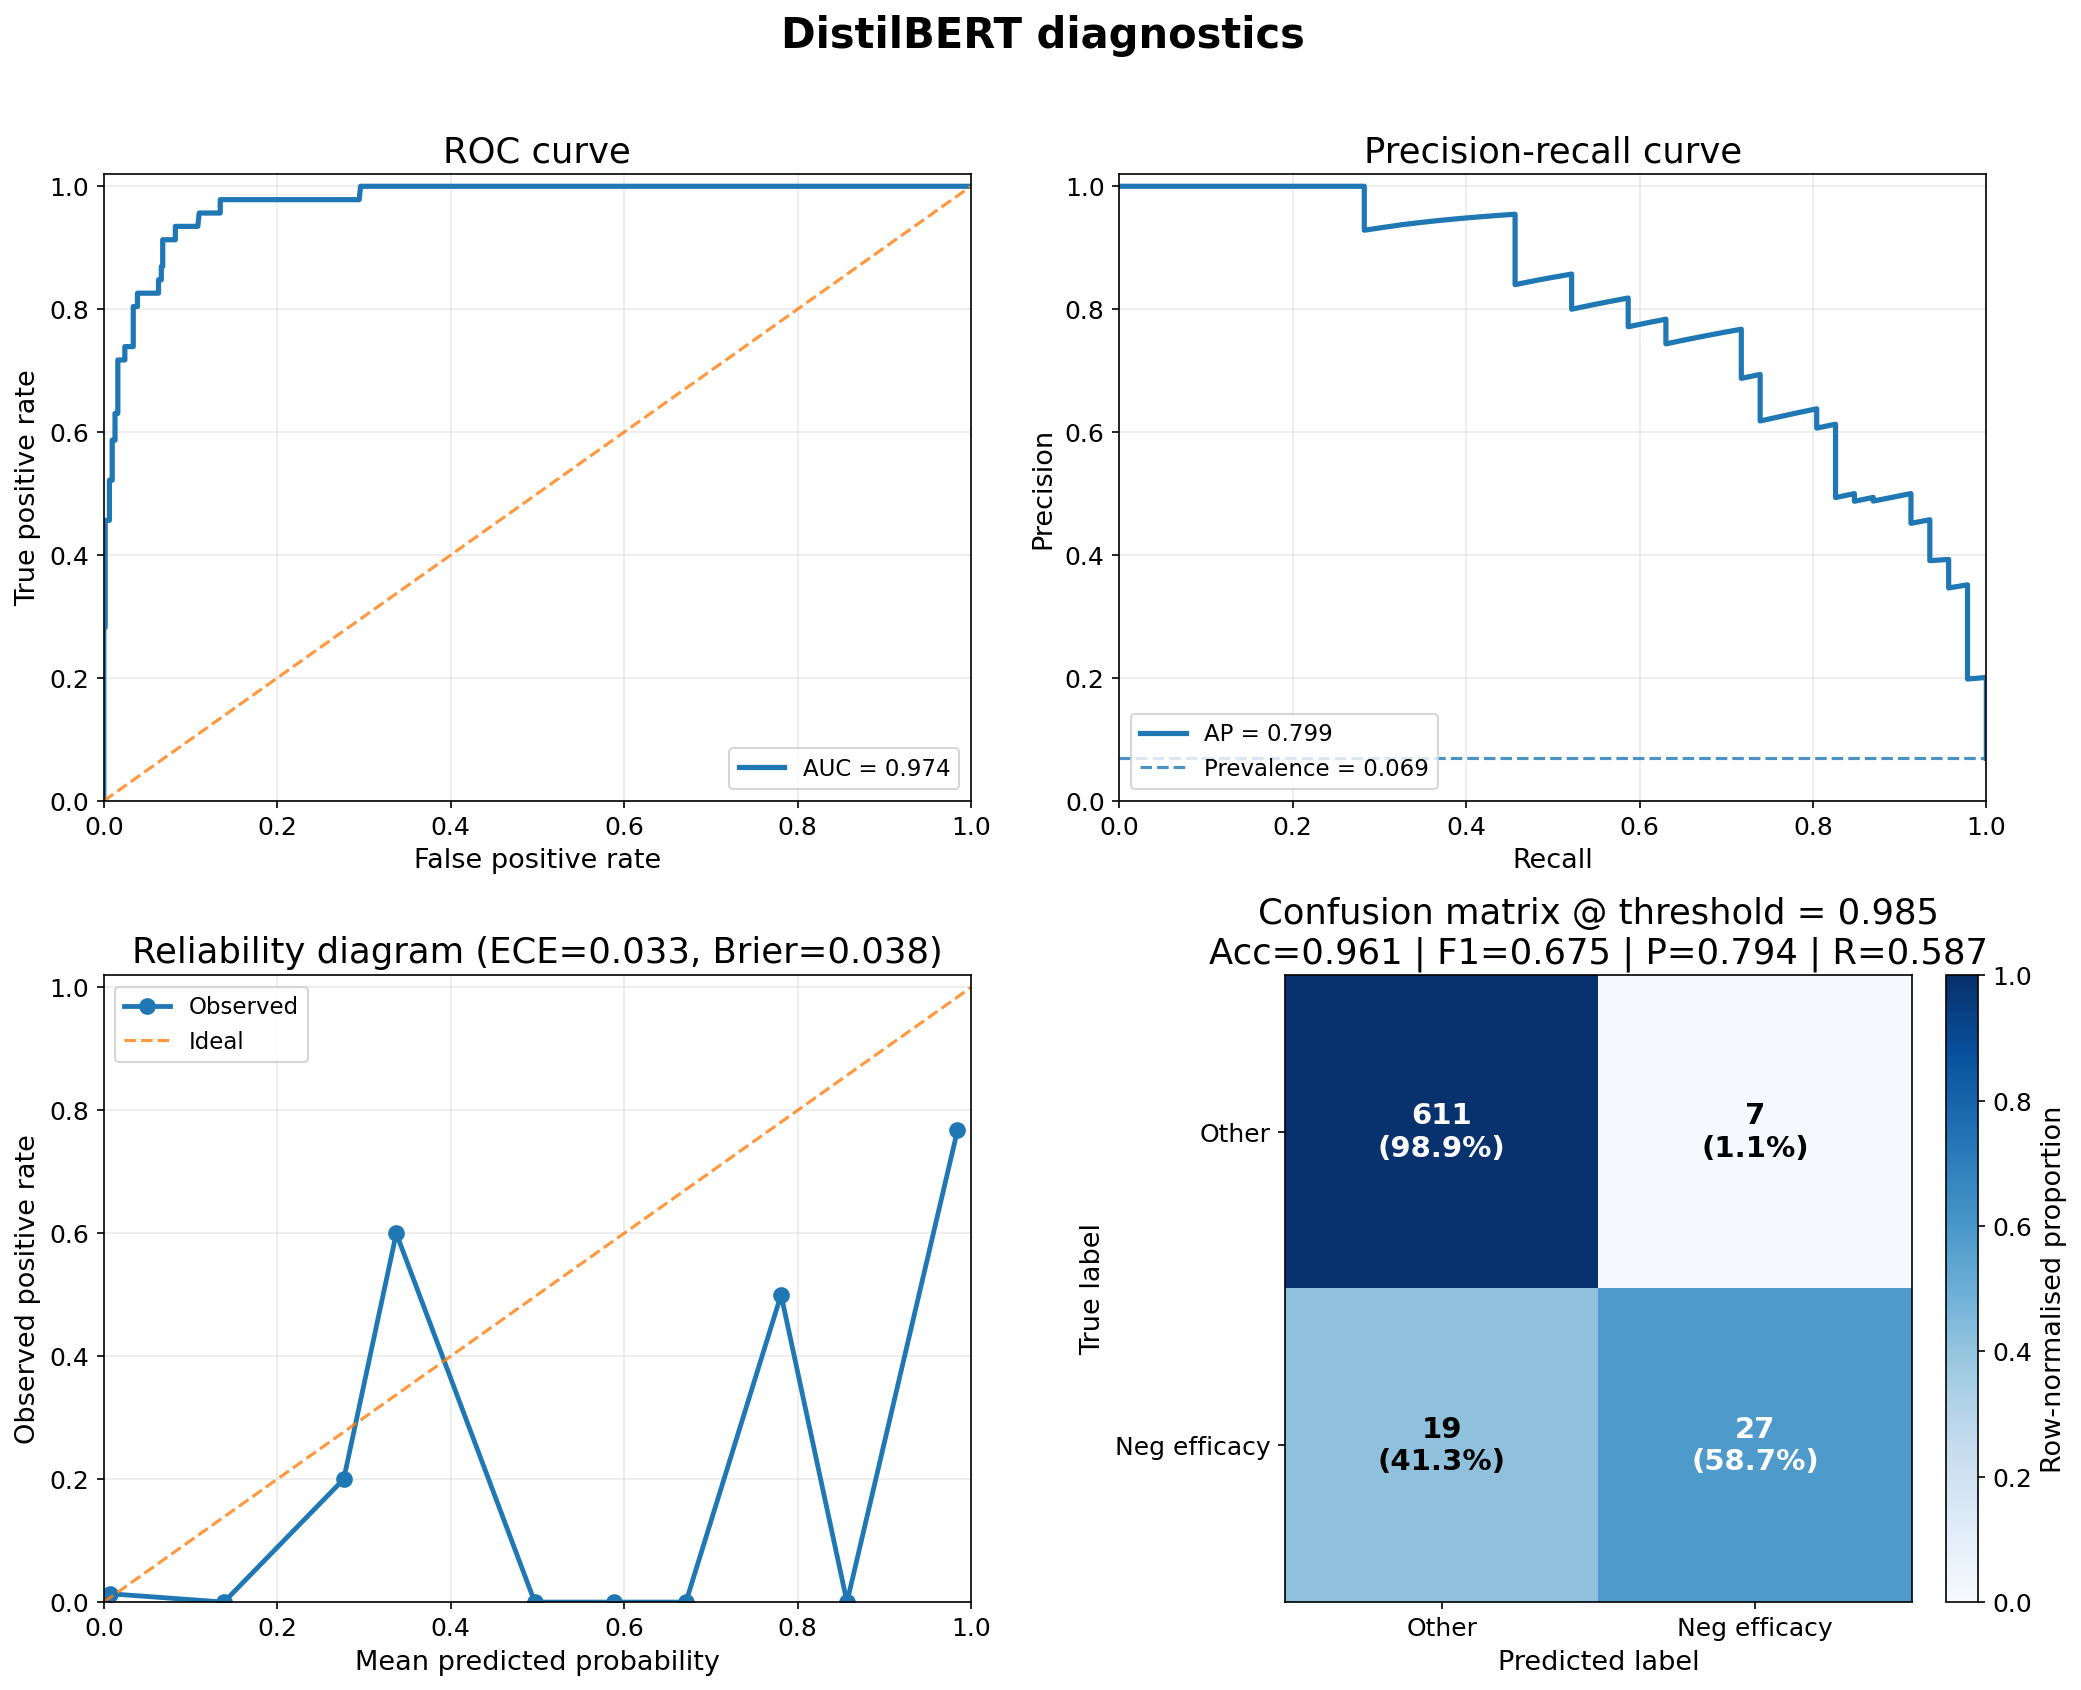

In [13]:
if MODELS_TO_RUN["distilbert"]:
    metrics, artifacts, aux = train_transformer_model(
        "distilbert",
        HF_MODELS["distilbert"],
        train_df,
        val_df,
        cal_df,
        test_df,
    )
    RESULTS["distilbert"] = metrics | {"model_name": HF_MODELS["distilbert"]}
    ARTIFACTS["distilbert"] = artifacts
    display(pd.DataFrame([RESULTS["distilbert"]]).T)
    plot_model_diagnostics(aux["y_test"], aux["test_prob"], threshold=artifacts["threshold"], title_prefix="DistilBERT")

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Average Precision,Roc Auc
1,0.481200,0.308749,0.951724,0.700000,0.636364,0.666667,0.755047,0.940723
2,0.259000,0.305969,0.955172,0.714286,0.681818,0.697674,0.801736,0.953358
3,0.155800,0.255432,0.962069,0.703704,0.863636,0.775510,0.818725,0.959803
4,0.047600,0.266819,0.962069,0.703704,0.863636,0.775510,0.818363,0.967436
5,0.003400,0.365037,0.958621,0.708333,0.772727,0.739130,0.806862,0.964722


,0
accuracy,0.968373
precision,0.727273
recall,0.869565
f1,0.792079
average_precision,0.878295
brier,0.02552
ece_10,0.023024
threshold,0.40101
roc_auc,0.983889
model_name,microsoft/BiomedNLP-BiomedBERT-base-uncased-ab...


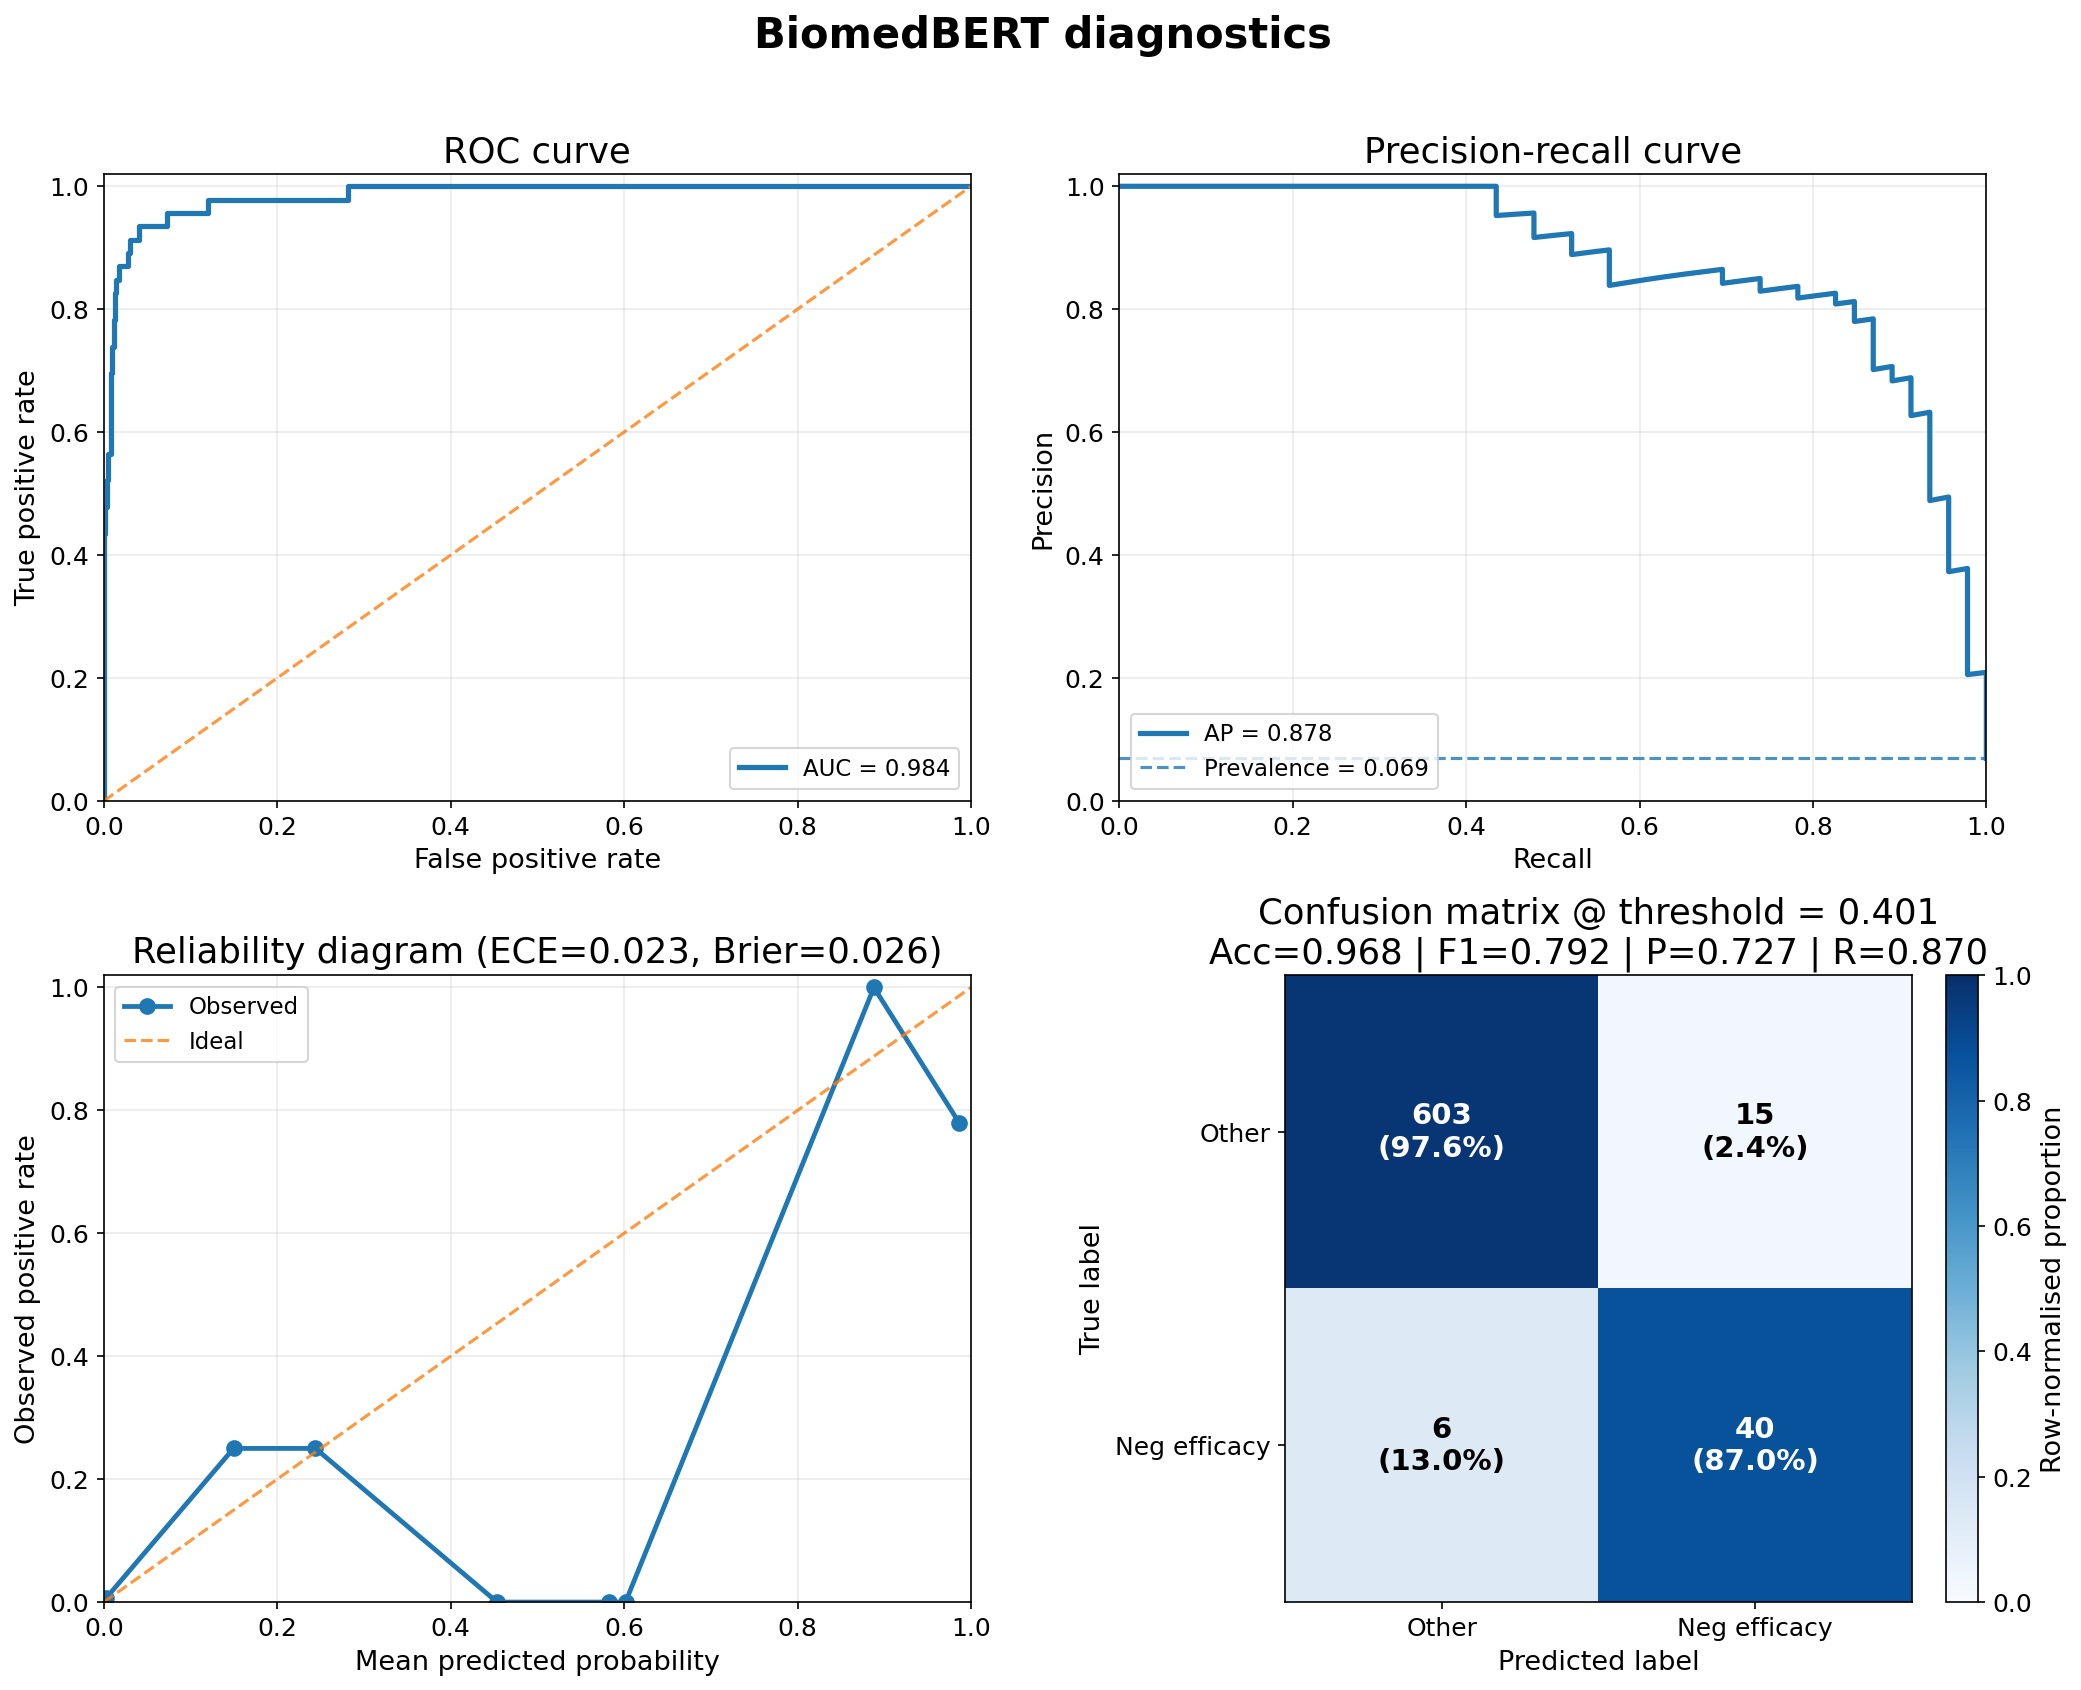

In [14]:
if MODELS_TO_RUN["biomedbert"]:
    metrics, artifacts, aux = train_transformer_model(
        "biomedbert",
        HF_MODELS["biomedbert"],
        train_df,
        val_df,
        cal_df,
        test_df,
    )
    RESULTS["biomedbert"] = metrics | {"model_name": HF_MODELS["biomedbert"]}
    ARTIFACTS["biomedbert"] = artifacts
    display(pd.DataFrame([RESULTS["biomedbert"]]).T)
    plot_model_diagnostics(aux["y_test"], aux["test_prob"], threshold=artifacts["threshold"], title_prefix="BiomedBERT")

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Average Precision,Roc Auc
1,0.543000,0.189803,0.962069,0.866667,0.590909,0.702703,0.863427,0.943775
2,0.273000,0.255511,0.972414,1.000000,0.636364,0.777778,0.862801,0.961075
3,0.117600,0.221451,0.962069,0.703704,0.863636,0.775510,0.852677,0.968708


,0
accuracy,0.960843
precision,0.692308
recall,0.782609
f1,0.734694
average_precision,0.807412
brier,0.027591
ece_10,0.011874
threshold,0.059495
roc_auc,0.957665
model_name,microsoft/deberta-v3-base


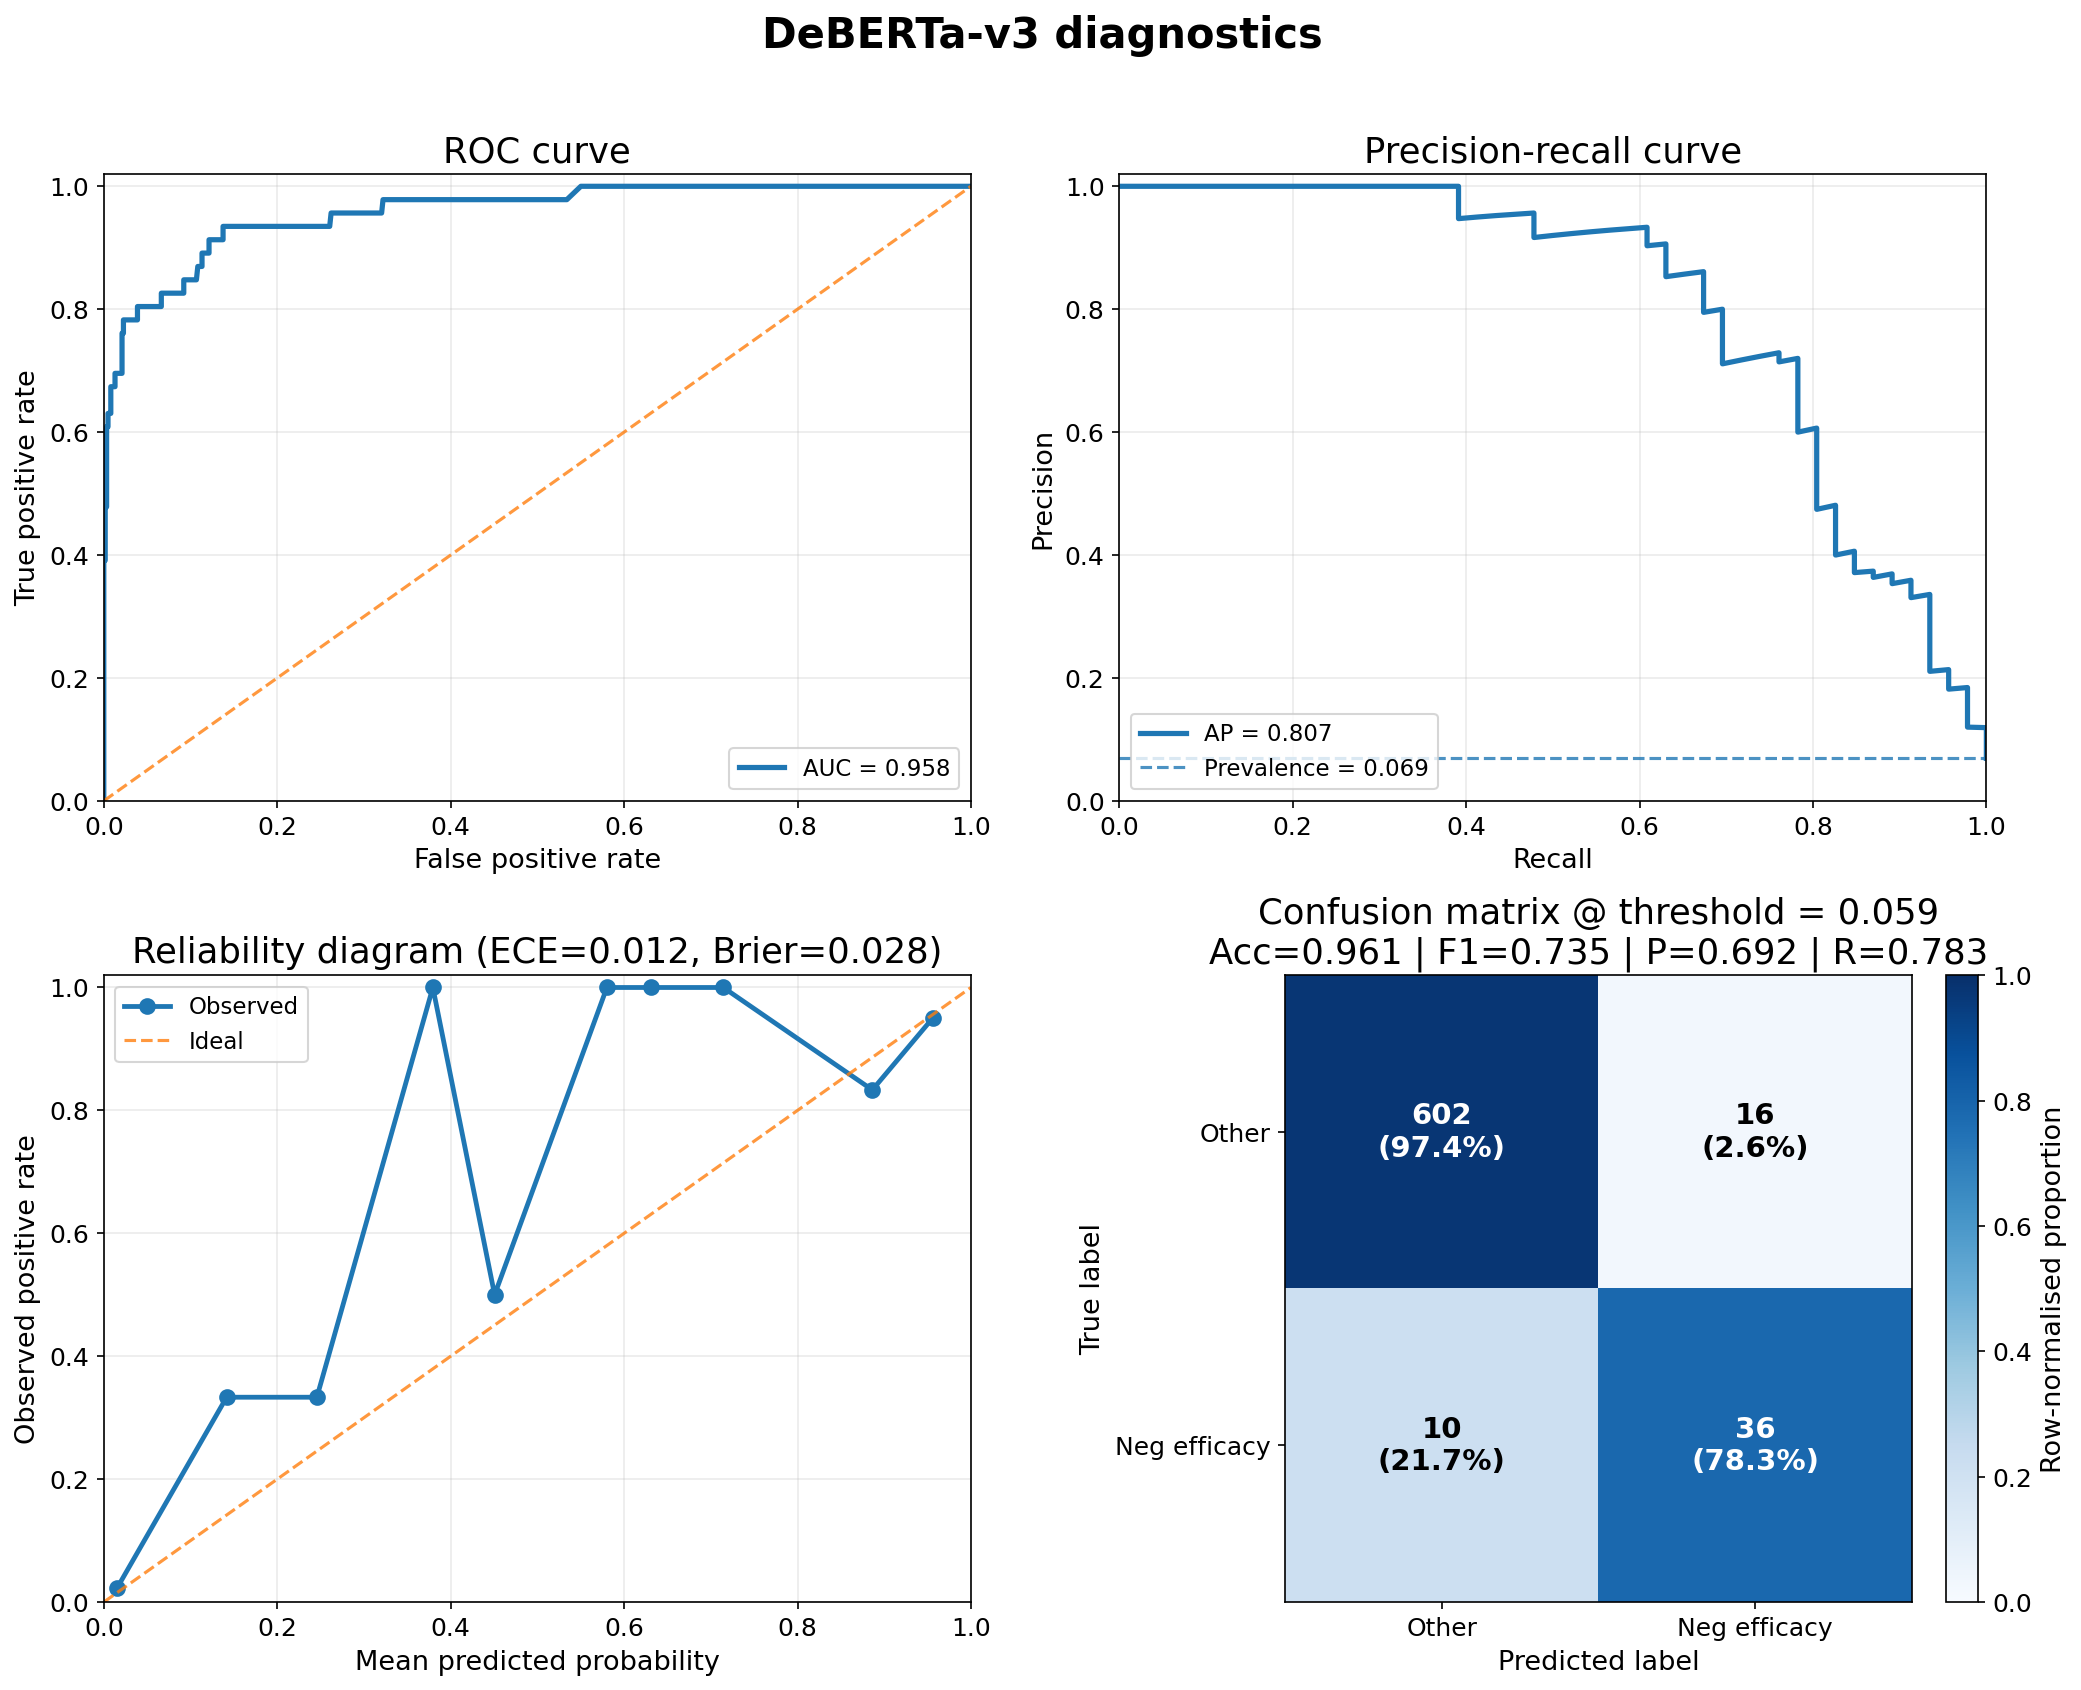

In [15]:
if MODELS_TO_RUN["deberta_v3"]:
    metrics, artifacts, aux = train_transformer_model(
        "deberta_v3",
        HF_MODELS["deberta_v3"],
        train_df,
        val_df,
        cal_df,
        test_df,
    )
    RESULTS["deberta_v3"] = metrics | {"model_name": HF_MODELS["deberta_v3"]}
    ARTIFACTS["deberta_v3"] = artifacts
    display(pd.DataFrame([RESULTS["deberta_v3"]]).T)
    plot_model_diagnostics(aux["y_test"], aux["test_prob"], threshold=artifacts["threshold"], title_prefix="DeBERTa-v3")


config.json:   0%|          | 0.00/594 [00:00<?, ?B/s]

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Applying column mapping to the training dataset
Applying column mapping to the evaluation dataset
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Map:   0%|          | 0/1748 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 69920
  Batch size = 64
  Num epochs = 1


Step,Training Loss
1,0.296800
50,0.266000
100,0.077700
150,0.020700
200,0.006800
250,0.004000
300,0.001700
350,0.002900
400,0.001300
450,0.001100


,0
accuracy,0.975904
precision,0.8
recall,0.869565
f1,0.833333
average_precision,0.882301
brier,0.021694
ece_10,0.014584
threshold,0.480202
roc_auc,0.944949
model_name,SetFit(sentence-transformers/paraphrase-mpnet-...


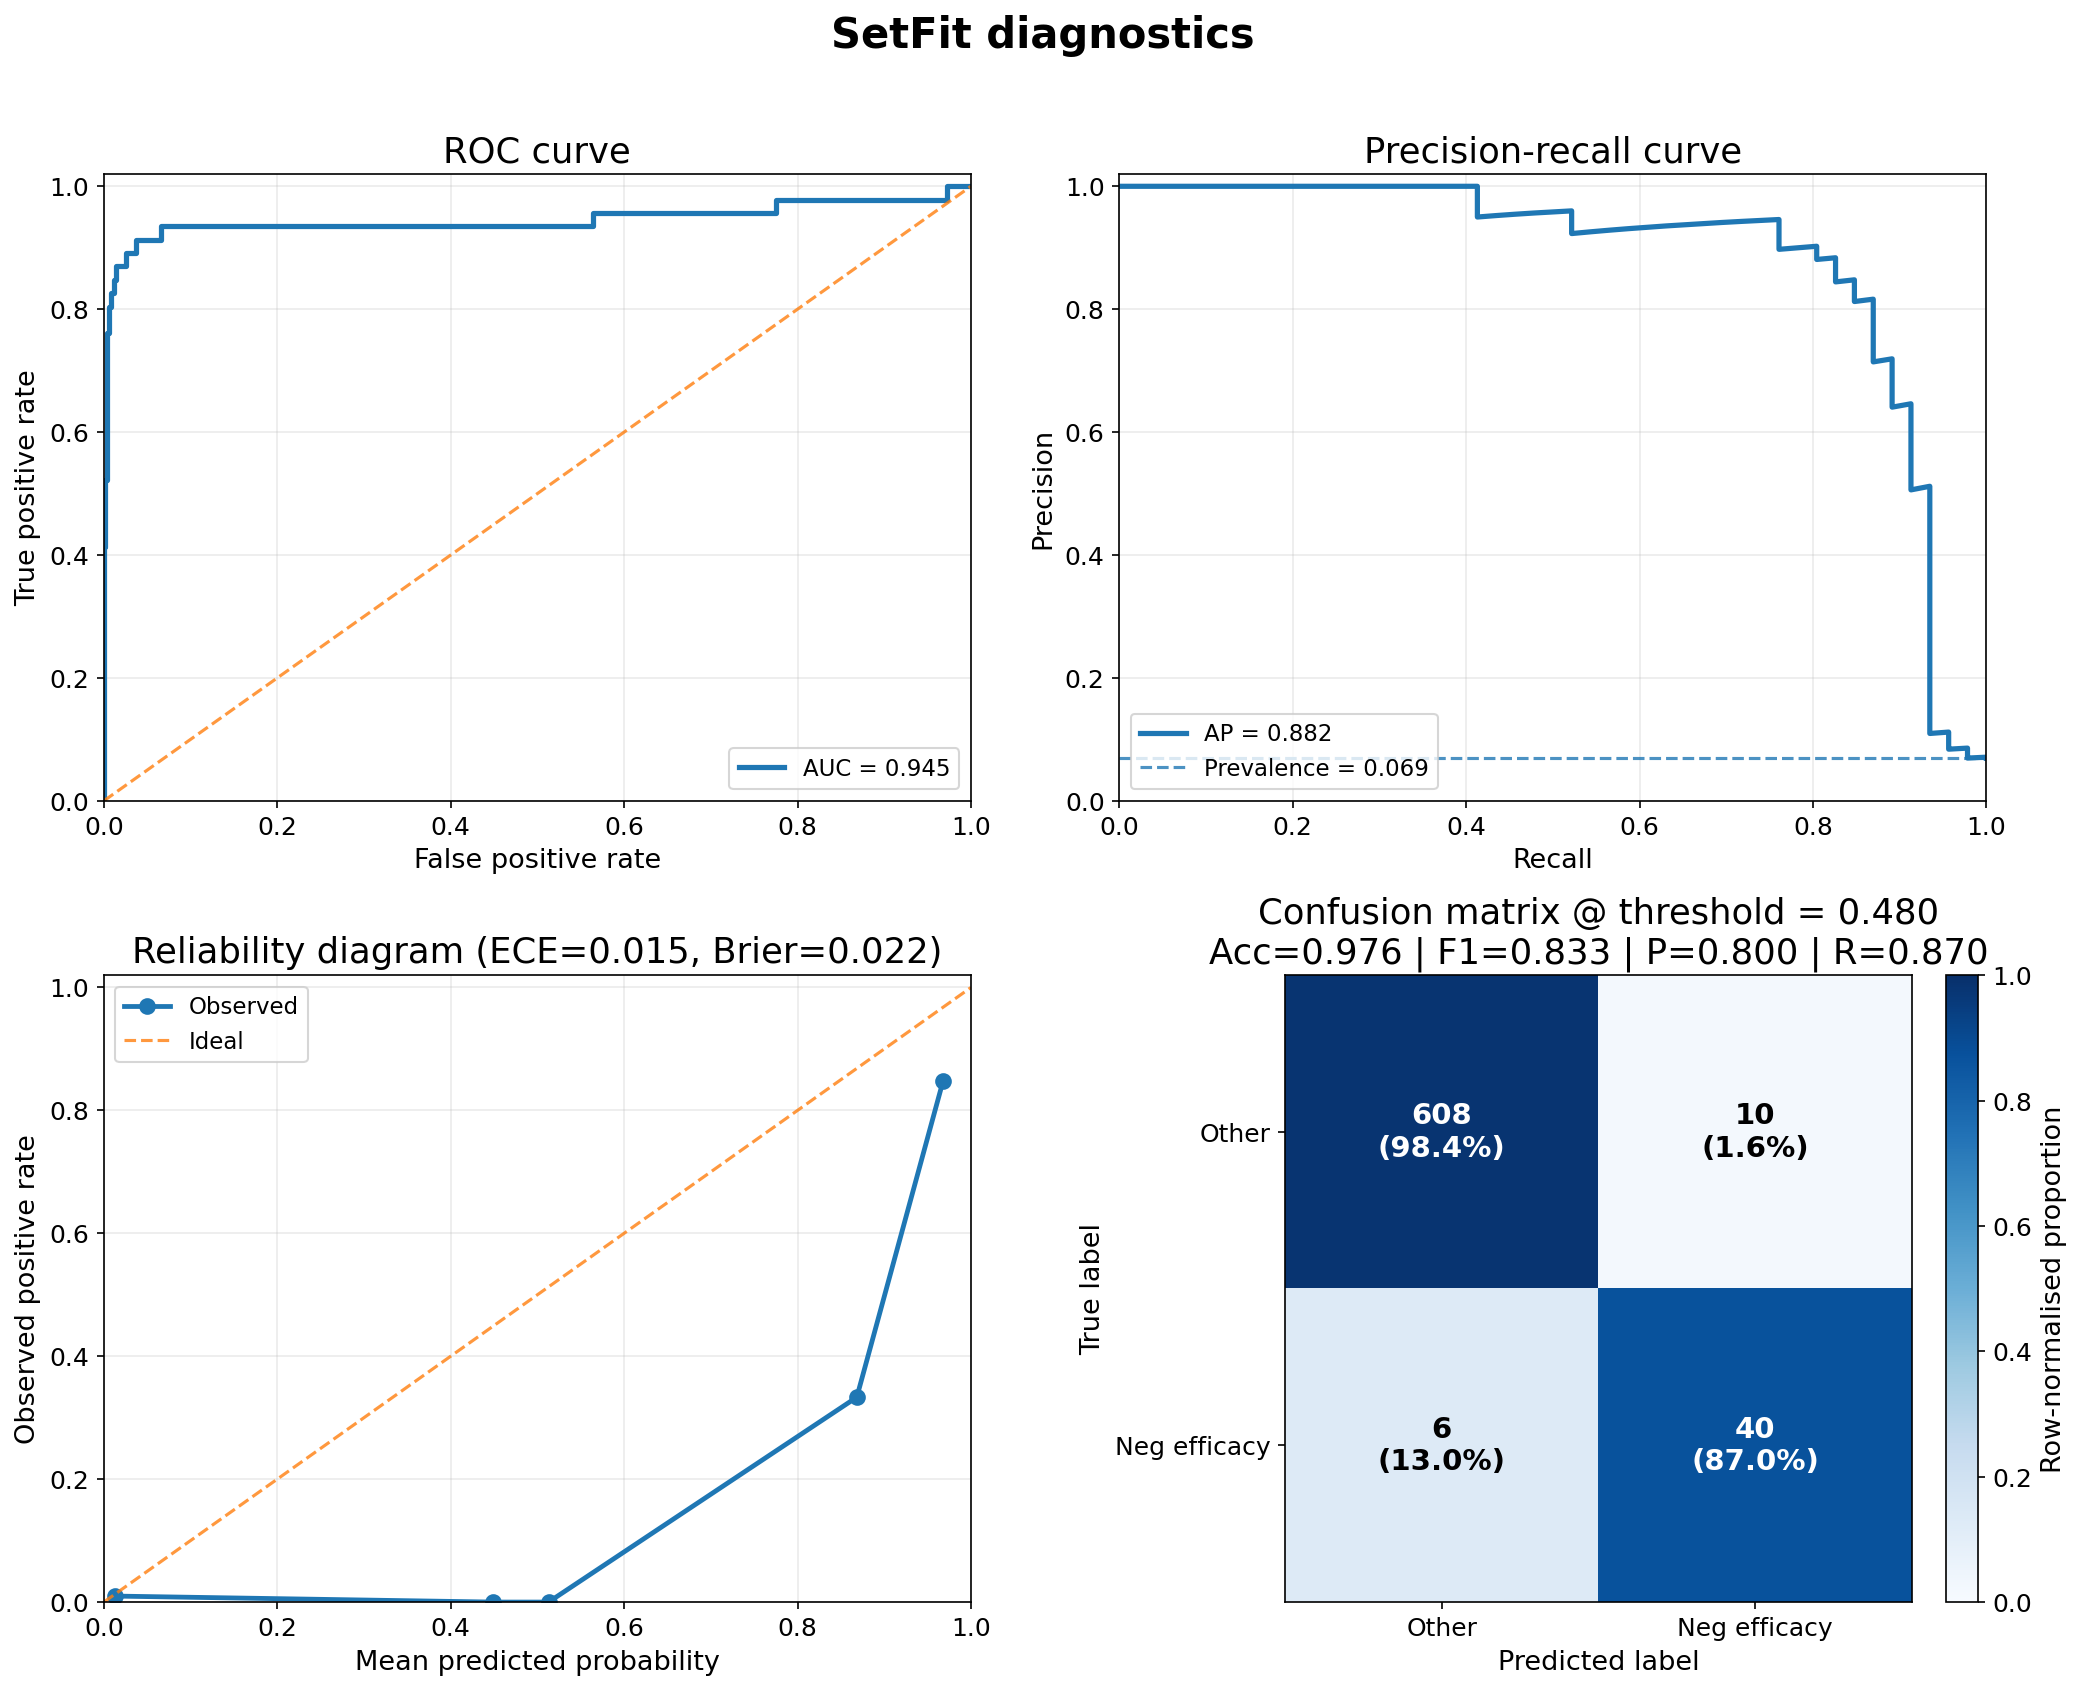

In [16]:
if MODELS_TO_RUN["setfit"]:
    metrics, artifacts, aux = train_setfit_model(
        "setfit",
        HF_MODELS["setfit"],
        train_df,
        val_df,
        cal_df,
        test_df,
    )
    RESULTS["setfit"] = metrics | {"model_name": f"SetFit({HF_MODELS['setfit']})"}
    ARTIFACTS["setfit"] = artifacts
    display(pd.DataFrame([RESULTS["setfit"]]).T)
    plot_model_diagnostics(aux["y_test"], aux["test_prob"], threshold=artifacts["threshold"], title_prefix="SetFit")


In [17]:
results_df = pd.DataFrame(RESULTS).T.sort_values(by=["average_precision", "f1", "roc_auc"], ascending=False)
display(results_df)
BEST_MODEL_KEY = results_df.index[0]
print("Selected best model:", BEST_MODEL_KEY)

,accuracy,precision,recall,f1,average_precision,brier,ece_10,threshold,roc_auc,model_name,best_C
setfit,0.975904,0.8,0.869565,0.833333,0.882301,0.021694,0.014584,0.480202,0.944949,SetFit(sentence-transformers/paraphrase-mpnet-...,NaN
biomedbert,0.968373,0.727273,0.869565,0.792079,0.878295,0.02552,0.023024,0.40101,0.983889,microsoft/BiomedNLP-BiomedBERT-base-uncased-ab...,NaN
logreg,0.962349,0.744186,0.695652,0.719101,0.832117,0.030301,0.02013,0.648485,0.978683,TFIDF+LogReg,4.0
deberta_v3,0.960843,0.692308,0.782609,0.734694,0.807412,0.027591,0.011874,0.059495,0.957665,microsoft/deberta-v3-base,NaN
distilbert,0.960843,0.794118,0.586957,0.675,0.79897,0.038216,0.033214,0.985051,0.973829,distilbert/distilbert-base-uncased,NaN


Selected best model: setfit


In [18]:
def _score_logreg(artifact, texts):
    X = artifact["vectorizer"].transform(list(texts))
    raw_scores = artifact["model"].decision_function(X)
    prob_pos = artifact["calibrator"].predict_proba(raw_scores)
    return prob_pos, raw_scores

def _score_transformer(artifact, texts):
    logits = predict_logits(
        artifact["model"],
        artifact["tokenizer"],
        list(texts),
        batch_size=EVAL_BATCH_SIZE,
        max_length=MAX_LEN,
    )
    prob_pos = apply_temperature(logits, artifact["temperature"])
    margin = np.abs(prob_pos - 0.5) * 2.0
    return prob_pos, margin

def _score_setfit(artifact, texts):
    prob_raw = _as_numpy(artifact["model"].predict_proba(list(texts)))[:, 1]
    raw_scores = _prob_to_logit(prob_raw)
    prob_pos = artifact["calibrator"].predict_proba(raw_scores)
    return prob_pos, raw_scores

def predict_texts(texts, model_key=None):
    if model_key is None:
        model_key = BEST_MODEL_KEY

    artifact = ARTIFACTS[model_key]
    texts = list(texts)

    if artifact["type"] == "logreg":
        prob_pos, secondary = _score_logreg(artifact, texts)
        confidence_name = "raw_log_odds"
    elif artifact["type"] == "setfit":
        prob_pos, secondary = _score_setfit(artifact, texts)
        confidence_name = "setfit_logit"
    else:
        prob_pos, secondary = _score_transformer(artifact, texts)
        confidence_name = "margin_from_0.5"

    pred_sets = conformal_prediction_sets(prob_pos, artifact["qhat"])
    point_preds = (prob_pos >= artifact["threshold"]).astype(int)

    rows = []
    for text, p1, pred, pred_set, sec in zip(texts, prob_pos, point_preds, pred_sets, secondary):
        if pred_set == [1]:
            decision = "predict_negative_efficacy"
        elif pred_set == [0]:
            decision = "predict_other_reason"
        else:
            decision = "review"

        rows.append({
            "text": text,
            "prob_negative_efficacy": float(p1),
            "point_prediction": int(pred),
            "prediction_set": str(pred_set),
            "decision": decision,
            confidence_name: float(sec),
        })
    return pd.DataFrame(rows)

demo_texts = [
    "Study was terminated after interim analysis showed futility and lack of efficacy.",
    "Trial stopped because of slow recruitment and lack of funding.",
    "Please see detailed description for termination reason.",
]
display(predict_texts(demo_texts))


,text,prob_negative_efficacy,point_prediction,prediction_set,decision,setfit_logit
0,Study was terminated after interim analysis sh...,0.973405,1,[1],predict_negative_efficacy,5.795215
1,Trial stopped because of slow recruitment and ...,0.012191,0,[0],predict_other_reason,-7.963785
2,Please see detailed description for terminatio...,0.012803,0,[0],predict_other_reason,-7.878398


In [19]:
def enable_dropout(model):
    for module in model.modules():
        if module.__class__.__name__.startswith("Dropout"):
            module.train()

def mc_dropout_predict_proba(model, tokenizer, texts, n_passes=20, batch_size=32, max_length=96):
    ds = TextDataset(texts, labels=None, tokenizer=tokenizer, max_length=max_length)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

    probs_passes = []
    model.eval()
    enable_dropout(model)

    with torch.no_grad():
        for _ in range(n_passes):
            probs_this_pass = []
            for batch in dl:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                logits = model(**batch).logits
                probs_this_pass.append(torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy())
            probs_passes.append(np.concatenate(probs_this_pass))

    probs_passes = np.stack(probs_passes, axis=0)
    return probs_passes.mean(axis=0), probs_passes.std(axis=0)

if BEST_MODEL_KEY in {"deberta_v3"}:
    mean_prob, std_prob = mc_dropout_predict_proba(
        ARTIFACTS[BEST_MODEL_KEY]["model"],
        ARTIFACTS[BEST_MODEL_KEY]["tokenizer"],
        demo_texts,
        n_passes=10,
        batch_size=8,
        max_length=MAX_LEN,
    )
    display(pd.DataFrame({
        "text": demo_texts,
        "mc_dropout_mean_prob": mean_prob,
        "mc_dropout_std": std_prob,
    }))
else:
    print("Best model is not a transformer with token-level dropout access; skipping MC dropout.")


Best model is not a transformer with token-level dropout access; skipping MC dropout.


In [23]:
# --- Razuvayevskaya / Open Targets comparison (current split + full-dataset cheated eval) ---
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification

MODEL_ID = "opentargets/clinical_trial_stop_reasons"
DEVICE_LOCAL = globals().get("DEVICE", "cuda" if torch.cuda.is_available() else "cpu")
MAX_LEN_LOCAL = globals().get("MAX_LEN", 96)
EVAL_BATCH_LOCAL = globals().get("EVAL_BATCH_SIZE", 32)

required_names = ["train_df", "val_df", "cal_df", "test_df"]
missing = [x for x in required_names if x not in globals()]
if missing:
    raise RuntimeError(f"Missing notebook variables required for comparison: {missing}")

def _find_negative_index(config):
    label2id = getattr(config, "label2id", None) or {}
    if "Negative" in label2id:
        return int(label2id["Negative"])

    id2label = getattr(config, "id2label", None) or {}
    for k, v in id2label.items():
        if str(v).strip().lower() == "negative":
            return int(k) if isinstance(k, str) and k.isdigit() else int(k)
    for k, v in id2label.items():
        if "negative" in str(v).strip().lower():
            return int(k) if isinstance(k, str) and k.isdigit() else int(k)

    raise ValueError(
        f"Could not find 'Negative' label in config. "
        f"label2id={label2id}, id2label={id2label}"
    )

class _SimpleTextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer, max_length=96):
        self.texts = list(texts)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {k: v.squeeze(0) for k, v in enc.items()}

def _predict_logits(texts, tokenizer, model, batch_size=32, max_length=96, device="cpu"):
    ds = _SimpleTextDataset(texts, tokenizer=tokenizer, max_length=max_length)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    all_logits = []
    model.eval()
    with torch.no_grad():
        for batch in dl:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits.detach().cpu().numpy()
            all_logits.append(logits)
    return np.concatenate(all_logits, axis=0)

def _negative_scores_and_probs(logits, config, neg_idx):
    logits = np.asarray(logits)

    if logits.ndim == 1:
        scores = logits.astype(float)
        probs = 1.0 / (1.0 + np.exp(-scores))
        return scores, probs

    problem_type = getattr(config, "problem_type", None)
    if problem_type == "single_label_classification":
        z = logits - logits.max(axis=1, keepdims=True)
        probs_all = np.exp(z) / np.exp(z).sum(axis=1, keepdims=True)
        scores = logits[:, neg_idx].astype(float)
        probs = probs_all[:, neg_idx].astype(float)
    else:
        scores = logits[:, neg_idx].astype(float)
        probs = 1.0 / (1.0 + np.exp(-scores))

    return scores, probs

def _binary_metrics(y_true, y_prob, threshold, split_name=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    row = {
        "AUROC": float(roc_auc_score(y_true, y_prob)),
        "AUPRC": float(average_precision_score(y_true, y_prob)),
        "B.Acc": float(balanced_accuracy_score(y_true, y_pred)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "Threshold": float(threshold),
        "N_eval": int(len(y_true)),
        "Pos_eval": int(y_true.sum()),
    }
    if split_name is not None:
        row["Eval_split"] = split_name
    return row

def _best_f1_threshold_local(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    thresholds = np.unique(np.concatenate([np.linspace(0.01, 0.99, 199), y_prob]))
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        preds = (y_prob >= t).astype(int)
        score = f1_score(y_true, preds, zero_division=0)
        if score > best_f1:
            best_t, best_f1 = float(t), float(score)
    return best_t, best_f1

cfg = AutoConfig.from_pretrained(MODEL_ID)
tok = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID).to(DEVICE_LOCAL)
neg_idx = _find_negative_index(cfg)

full_df = pd.concat([train_df, val_df, cal_df, test_df], axis=0, ignore_index=True)

# Current notebook split evaluation: threshold selected on val after Platt fit on cal, evaluated on test
val_logits = _predict_logits(
    val_df["text"].tolist(), tok, model,
    batch_size=EVAL_BATCH_LOCAL, max_length=MAX_LEN_LOCAL, device=DEVICE_LOCAL
)
cal_logits = _predict_logits(
    cal_df["text"].tolist(), tok, model,
    batch_size=EVAL_BATCH_LOCAL, max_length=MAX_LEN_LOCAL, device=DEVICE_LOCAL
)
test_logits = _predict_logits(
    test_df["text"].tolist(), tok, model,
    batch_size=EVAL_BATCH_LOCAL, max_length=MAX_LEN_LOCAL, device=DEVICE_LOCAL
)

val_scores, val_prob_raw = _negative_scores_and_probs(val_logits, cfg, neg_idx)
cal_scores, cal_prob_raw = _negative_scores_and_probs(cal_logits, cfg, neg_idx)
test_scores, test_prob_raw = _negative_scores_and_probs(test_logits, cfg, neg_idx)

platt_split = LogisticRegression(solver="lbfgs", max_iter=2000)
platt_split.fit(cal_scores.reshape(-1, 1), cal_df["label"].astype(int).to_numpy())

val_prob = platt_split.predict_proba(val_scores.reshape(-1, 1))[:, 1]
test_prob = platt_split.predict_proba(test_scores.reshape(-1, 1))[:, 1]

threshold_split, best_val_f1 = _best_f1_threshold_local(val_df["label"].to_numpy(), val_prob)
ot_metrics_split = _binary_metrics(
    test_df["label"].to_numpy(),
    test_prob,
    threshold=threshold_split,
    split_name="test (threshold from val, Platt on cal)",
)
open_targets_row_split = {
    "Method": "Open Targets / Razuvayevskaya HF model (current split eval)",
    "Source": "Released HF model, evaluated on notebook val/cal/test split",
    **ot_metrics_split,
    "Published_Fmicro": np.nan,
    "Comparable?": "Closest binary proxy",
}

# Full-dataset cheated evaluation: Platt fit and threshold selection on the same full dataset, then eval on full dataset
full_logits = _predict_logits(
    full_df["text"].tolist(), tok, model,
    batch_size=EVAL_BATCH_LOCAL, max_length=MAX_LEN_LOCAL, device=DEVICE_LOCAL
)
full_scores, full_prob_raw = _negative_scores_and_probs(full_logits, cfg, neg_idx)

platt_full = LogisticRegression(solver="lbfgs", max_iter=2000)
platt_full.fit(full_scores.reshape(-1, 1), full_df["label"].astype(int).to_numpy())
full_prob = platt_full.predict_proba(full_scores.reshape(-1, 1))[:, 1]

threshold_full, best_full_f1 = _best_f1_threshold_local(full_df["label"].to_numpy(), full_prob)
ot_metrics_full = _binary_metrics(
    full_df["label"].to_numpy(),
    full_prob,
    threshold=threshold_full,
    split_name="full dataset (fit+threshold+eval all on same data)",
)
open_targets_row_full = {
    "Method": "Open Targets / Razuvayevskaya HF model (full-dataset cheated eval)",
    "Source": "Released HF model, Platt+threshold+eval on same full dataset",
    **ot_metrics_full,
    "Published_Fmicro": np.nan,
    "Comparable?": "Closer, but in-sample / cheated",
}

RAZUVAYEVSKAYA_COMPARISON_ROWS = [
    open_targets_row_split,
    open_targets_row_full,
]

RAZUVAYEVSKAYA_COMPARISON = {
    "model_id": MODEL_ID,
    "negative_label_index": neg_idx,
    "threshold_split": threshold_split,
    "threshold_full": threshold_full,
    "best_val_f1": best_val_f1,
    "best_full_f1": best_full_f1,
    "rows": RAZUVAYEVSKAYA_COMPARISON_ROWS,
    "test_prob": test_prob,
    "full_prob": full_prob,
}

print(f"Loaded {MODEL_ID}")
print(f"Negative label index: {neg_idx}")
print(f"Current split threshold: {threshold_split:.4f} | best val F1={best_val_f1:.4f}")
print(f"Full cheated threshold:  {threshold_full:.4f} | best full F1={best_full_f1:.4f}")

display(pd.DataFrame(RAZUVAYEVSKAYA_COMPARISON_ROWS)[[
    "Method", "Source", "Eval_split", "AUROC", "AUPRC", "B.Acc", "F1", "Threshold", "N_eval", "Pos_eval", "Comparable?"
]])

Loaded opentargets/clinical_trial_stop_reasons
Negative label index: 10
Current split threshold: 0.4852 | best val F1=0.8182
Full cheated threshold:  0.6830 | best full F1=0.8313


,Method,Source,Eval_split,AUROC,AUPRC,B.Acc,F1,Threshold,N_eval,Pos_eval,Comparable?
0,Open Targets / Razuvayevskaya HF model (curren...,"Released HF model, evaluated on notebook val/c...","test (threshold from val, Platt on cal)",0.969924,0.769601,0.925074,0.816327,0.485152,664,46,Closest binary proxy
1,Open Targets / Razuvayevskaya HF model (full-d...,"Released HF model, Platt+threshold+eval on sam...",full dataset (fit+threshold+eval all on same d...,0.979618,0.801623,0.923712,0.831325,0.683032,3022,239,"Closer, but in-sample / cheated"


In [24]:
# --- Cheated BiomedBERT full-dataset proxy ---
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score

CHEATED_PROXY_KEY = "biomedbert_cheated_proxy_full_dataset"
CHEATED_PROXY_MODEL_NAME = globals().get(
    "HF_MODELS",
    {},
).get(
    "biomedbert",
    "microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext",
)

if "train_transformer_model" not in globals():
    raise RuntimeError("train_transformer_model must already be defined before running this cell.")

full_df = pd.concat([train_df, val_df, cal_df, test_df], axis=0, ignore_index=True)
y_full = full_df["label"].to_numpy().astype(int)

def _binary_metrics(y_true, y_prob, threshold, split_name=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    row = {
        "AUROC": float(roc_auc_score(y_true, y_prob)),
        "AUPRC": float(average_precision_score(y_true, y_prob)),
        "B.Acc": float(balanced_accuracy_score(y_true, y_pred)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "Threshold": float(threshold),
        "N_eval": int(len(y_true)),
        "Pos_eval": int(y_true.sum()),
    }
    if split_name is not None:
        row["Eval_split"] = split_name
    return row

if "ARTIFACTS" in globals() and CHEATED_PROXY_KEY in ARTIFACTS:
    cheated_artifact = ARTIFACTS[CHEATED_PROXY_KEY]
    cheated_prob, _ = _score_transformer(cheated_artifact, full_df["text"].tolist())
    cheated_threshold = float(cheated_artifact["threshold"])
else:
    cheated_metrics_raw, cheated_artifact, cheated_aux = train_transformer_model(
        CHEATED_PROXY_KEY,
        CHEATED_PROXY_MODEL_NAME,
        full_df,
        full_df,
        full_df,
        full_df,
    )
    if "ARTIFACTS" in globals():
        ARTIFACTS[CHEATED_PROXY_KEY] = cheated_artifact
    if "RESULTS" in globals():
        RESULTS[CHEATED_PROXY_KEY] = cheated_metrics_raw | {
            "model_name": CHEATED_PROXY_MODEL_NAME,
            "note": "cheated full-dataset fit/eval proxy",
        }
    cheated_prob = np.asarray(cheated_aux["test_prob"]).astype(float)
    cheated_threshold = float(cheated_artifact["threshold"])

cheated_metrics = _binary_metrics(
    y_full,
    cheated_prob,
    threshold=cheated_threshold,
    split_name="full dataset (fit+eval on same data)",
)

CHEATED_BIOMEDBERT_PROXY_ROW = {
    "Method": "BiomedBERT cheated proxy (fit+eval on full dataset)",
    "Source": "This notebook (same full dataset used for train/val/cal/test)",
    **cheated_metrics,
    "Published_Fmicro": np.nan,
    "Comparable?": "Closer, but in-sample / cheated",
}

CHEATED_BIOMEDBERT_PROXY_COMPARISON = {
    "model_name": CHEATED_PROXY_MODEL_NAME,
    "row": CHEATED_BIOMEDBERT_PROXY_ROW,
    "comparison_df": pd.DataFrame([CHEATED_BIOMEDBERT_PROXY_ROW]),
    "note": "BiomedBERT fit and evaluated on the same full dataset used in this notebook.",
}

print(f"Cheated proxy model: {CHEATED_PROXY_MODEL_NAME}")
display(pd.DataFrame([CHEATED_BIOMEDBERT_PROXY_ROW])[[
    "Method", "Source", "Eval_split", "AUROC", "AUPRC", "B.Acc", "F1", "Threshold", "N_eval", "Pos_eval", "Comparable?"
]])

Cheated proxy model: microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext


,Method,Source,Eval_split,AUROC,AUPRC,B.Acc,F1,Threshold,N_eval,Pos_eval,Comparable?
0,BiomedBERT cheated proxy (fit+eval on full dat...,This notebook (same full dataset used for trai...,full dataset (fit+eval on same data),0.999995,0.999948,0.999641,0.995833,0.01,3022,239,"Closer, but in-sample / cheated"


In [35]:
# --- Comparison table for printing / slide export ---
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score

comparison_rows = []

if "RAZUVAYEVSKAYA_COMPARISON_ROWS" not in globals():
    raise RuntimeError("Run the Razuvayevskaya comparison cell first.")
comparison_rows.extend(RAZUVAYEVSKAYA_COMPARISON_ROWS)

if "CHEATED_BIOMEDBERT_PROXY_ROW" not in globals():
    raise RuntimeError("Run the cheated BiomedBERT proxy cell first.")
comparison_rows.append(CHEATED_BIOMEDBERT_PROXY_ROW)

if "ARTIFACTS" in globals():
    y_true = test_df["label"].to_numpy().astype(int)
    for model_key, artifact in ARTIFACTS.items():
        if model_key == "biomedbert_cheated_proxy_full_dataset":
            continue

        if artifact["type"] == "logreg":
            prob_pos, _ = _score_logreg(artifact, test_df["text"].tolist())
        elif artifact["type"] == "setfit":
            prob_pos, _ = _score_setfit(artifact, test_df["text"].tolist())
        else:
            prob_pos, _ = _score_transformer(artifact, test_df["text"].tolist())

        y_pred = (prob_pos >= artifact["threshold"]).astype(int)

        comparison_rows.append({
            "Method": RESULTS.get(model_key, {}).get("model_name", model_key),
            "Source": "This notebook",
            "Eval_split": "test",
            "AUROC": float(roc_auc_score(y_true, prob_pos)),
            "AUPRC": float(average_precision_score(y_true, prob_pos)),
            "B.Acc": float(balanced_accuracy_score(y_true, y_pred)),
            "F1": float(f1_score(y_true, y_pred, zero_division=0)),
            "Threshold": float(artifact["threshold"]),
            "N_eval": int(len(y_true)),
            "Pos_eval": int(y_true.sum()),
            "Published_Fmicro": np.nan,
            "Comparable?": "Yes",
        })

slide_reference_rows = [
    {"Method": "TF-IDF + Linear Regression", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.963, "AUPRC": 0.736, "B.Acc": 0.846, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "TF-IDF + Random Forest", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.954, "AUPRC": 0.688, "B.Acc": 0.745, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "fastText + Linear Regression", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.892, "AUPRC": 0.469, "B.Acc": 0.824, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Mostly"},
    {"Method": "fastText + Random Forest", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.844, "AUPRC": 0.436, "B.Acc": 0.531, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Mostly"},
    {"Method": "GPT-5-nano zero-shot", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.919, "AUPRC": 0.655, "B.Acc": 0.833, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-nano zero-shot + cue", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.924, "AUPRC": 0.617, "B.Acc": 0.826, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-nano few-shot", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.932, "AUPRC": 0.604, "B.Acc": 0.870, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-mini few-shot (10 demos)", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.950, "AUPRC": 0.650, "B.Acc": 0.860, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-mini few-shot + rationale", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.950, "AUPRC": 0.596, "B.Acc": 0.876, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-mini few-shot + rationale + self-consistency", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.950, "AUPRC": 0.650, "B.Acc": 0.860, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-mini RAG top-10", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.928, "AUPRC": 0.653, "B.Acc": 0.880, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
    {"Method": "GPT-5-mini RAG top-10 + self-consistency", "Source": "Group presentation", "Eval_split": "published slide test", "AUROC": 0.942, "AUPRC": 0.671, "B.Acc": 0.881, "F1": np.nan, "Threshold": np.nan, "N_eval": 543, "Pos_eval": 47, "Published_Fmicro": np.nan, "Comparable?": "Yes"},
]
comparison_rows.extend(slide_reference_rows)

comparison_rows.append({
    "Method": "Razuvayevskaya et al. 2024 paper result",
    "Source": "Published paper",
    "Eval_split": "paper setting",
    "AUROC": np.nan,
    "AUPRC": np.nan,
    "B.Acc": np.nan,
    "F1": np.nan,
    "Threshold": np.nan,
    "N_eval": np.nan,
    "Pos_eval": np.nan,
    "Published_Fmicro": "0.91 cross-val; 0.70–0.83 external",
    "Comparable?": "No - 17-label multi-label task",
})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["_sort_auc"] = comparison_df["AUROC"].fillna(-1.0)
comparison_df = (
    comparison_df
    .sort_values(["_sort_auc", "AUPRC", "B.Acc"], ascending=False)
    .drop(columns="_sort_auc")
    .reset_index(drop=True)
)

comparison_print_df = comparison_df[[
    "Method", "Source", "Eval_split", "AUROC", "AUPRC", "B.Acc", "F1",
    "Published_Fmicro", "Comparable?"
]].copy()

print("Note: the full-dataset Razuvayevskaya and BiomedBERT rows are intentionally cheated/in-sample upper-bound comparisons.")
display(comparison_df)
display(comparison_print_df)

Note: the full-dataset Razuvayevskaya and BiomedBERT rows are intentionally cheated/in-sample upper-bound comparisons.


,Method,Source,AUROC,AUPRC,B.Acc,F1,Threshold,N_eval,Pos_eval,Eval_split,Published_Fmicro,Comparable?
0,BiomedBERT cheated proxy (fit+eval on full dat...,This notebook (same full dataset used for trai...,0.999995,0.999948,0.999641,0.995833,0.010000,3022.0,239.0,full dataset (fit+eval on same data),NaN,"Closer, but in-sample / cheated"
1,microsoft/BiomedNLP-BiomedBERT-base-uncased-ab...,This notebook,0.983889,0.878295,0.922647,0.792079,0.401010,664.0,46.0,test,NaN,Yes
2,Open Targets / Razuvayevskaya HF model (full-d...,"Released HF model, Platt+threshold+eval on sam...",0.979618,0.801623,0.923712,0.831325,0.683032,3022.0,239.0,full dataset (fit+threshold+eval all on same d...,NaN,"Closer, but in-sample / cheated"
3,TFIDF+LogReg,This notebook,0.978683,0.832117,0.838926,0.719101,0.648485,664.0,46.0,test,NaN,Yes
4,distilbert/distilbert-base-uncased,This notebook,0.973829,0.798970,0.787815,0.675000,0.985051,664.0,46.0,test,NaN,Yes
5,Open Targets / Razuvayevskaya HF model (curren...,"Released HF model, evaluated on notebook val/c...",0.969924,0.769601,0.925074,0.816327,0.485152,664.0,46.0,"test (threshold from val, Platt on cal)",NaN,Closest binary proxy
6,TF-IDF + Linear Regression,Group presentation,0.963000,0.736000,0.846000,NaN,NaN,543.0,47.0,published slide test,NaN,Yes
7,microsoft/deberta-v3-base,This notebook,0.957665,0.807412,0.878359,0.734694,0.059495,664.0,46.0,test,NaN,Yes
8,TF-IDF + Random Forest,Group presentation,0.954000,0.688000,0.745000,NaN,NaN,543.0,47.0,published slide test,NaN,Yes
9,GPT-5-mini few-shot (10 demos),Group presentation,0.950000,0.650000,0.860000,NaN,NaN,543.0,47.0,published slide test,NaN,Yes


,Method,Source,Eval_split,AUROC,AUPRC,B.Acc,F1,Published_Fmicro,Comparable?
0,BiomedBERT cheated proxy (fit+eval on full dat...,This notebook (same full dataset used for trai...,full dataset (fit+eval on same data),0.999995,0.999948,0.999641,0.995833,NaN,"Closer, but in-sample / cheated"
1,microsoft/BiomedNLP-BiomedBERT-base-uncased-ab...,This notebook,test,0.983889,0.878295,0.922647,0.792079,NaN,Yes
2,Open Targets / Razuvayevskaya HF model (full-d...,"Released HF model, Platt+threshold+eval on sam...",full dataset (fit+threshold+eval all on same d...,0.979618,0.801623,0.923712,0.831325,NaN,"Closer, but in-sample / cheated"
3,TFIDF+LogReg,This notebook,test,0.978683,0.832117,0.838926,0.719101,NaN,Yes
4,distilbert/distilbert-base-uncased,This notebook,test,0.973829,0.798970,0.787815,0.675000,NaN,Yes
5,Open Targets / Razuvayevskaya HF model (curren...,"Released HF model, evaluated on notebook val/c...","test (threshold from val, Platt on cal)",0.969924,0.769601,0.925074,0.816327,NaN,Closest binary proxy
6,TF-IDF + Linear Regression,Group presentation,published slide test,0.963000,0.736000,0.846000,NaN,NaN,Yes
7,microsoft/deberta-v3-base,This notebook,test,0.957665,0.807412,0.878359,0.734694,NaN,Yes
8,TF-IDF + Random Forest,Group presentation,published slide test,0.954000,0.688000,0.745000,NaN,NaN,Yes
9,GPT-5-mini few-shot (10 demos),Group presentation,published slide test,0.950000,0.650000,0.860000,NaN,NaN,Yes


In [21]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def export_artifacts(results_df, export_dir=EXPORT_DIR):
    export_dir.mkdir(parents=True, exist_ok=True)

    summary = {
        "sheet_name": SHEET_NAME,
        "text_col": TEXT_COL,
        "label_cols": LABEL_COLS,
        "positive_reason_labels": sorted(POSITIVE_REASON_LABELS | RELAXED_EXTRA_POSITIVE_LABELS),
        "best_model_key": BEST_MODEL_KEY,
        "results": results_df.reset_index(names="model_key").to_dict(orient="records"),
    }
    with open(export_dir / "run_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    for model_key, artifact in ARTIFACTS.items():
        if artifact["type"] == "logreg":
            joblib.dump({
                "vectorizer": artifact["vectorizer"],
                "model": artifact["model"],
                "calibrator": artifact["calibrator"],
                "threshold": artifact["threshold"],
                "qhat": artifact["qhat"],
                "positive_reason_labels": artifact["positive_reason_labels"],
            }, export_dir / f"{model_key}_bundle.joblib")
        elif artifact["type"] == "setfit":
            model_dir = export_dir / model_key
            model_dir.mkdir(exist_ok=True, parents=True)
            artifact["model"].save_pretrained(model_dir)
            joblib.dump(artifact["calibrator"], model_dir / "calibrator.joblib")
            with open(model_dir / "posthoc_config.json", "w") as f:
                json.dump({
                    "model_name": artifact["model_name"],
                    "threshold": artifact["threshold"],
                    "qhat": artifact["qhat"],
                    "positive_reason_labels": artifact["positive_reason_labels"],
                }, f, indent=2)
        else:
            model_dir = export_dir / model_key
            model_dir.mkdir(exist_ok=True, parents=True)
            artifact["model"].save_pretrained(model_dir)
            artifact["tokenizer"].save_pretrained(model_dir)
            with open(model_dir / "posthoc_config.json", "w") as f:
                json.dump({
                    "model_name": artifact["model_name"],
                    "temperature": artifact["temperature"],
                    "threshold": artifact["threshold"],
                    "qhat": artifact["qhat"],
                    "positive_reason_labels": artifact["positive_reason_labels"],
                }, f, indent=2)

    zip_path = shutil.make_archive(str(export_dir), "zip", export_dir)
    return Path(zip_path)

zip_path = export_artifacts(results_df, EXPORT_DIR)
print("Exported:", zip_path)

if IN_COLAB:
    files.download(str(zip_path))


Exported: /content/negative_efficacy_export.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
# --- Export data splits for download ---
import os
import json
import zipfile
from pathlib import Path

OUT_DIR = Path("exported_splits")
OUT_DIR.mkdir(exist_ok=True, parents=True)

required = ["train_df", "val_df", "cal_df", "test_df"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing expected split variables: {missing}")

split_map = {
    "train": train_df.copy(),
    "val": val_df.copy(),
    "cal": cal_df.copy(),
    "test": test_df.copy(),
}

summary_rows = []
for split_name, df_ in split_map.items():
    out_csv = OUT_DIR / f"{split_name}.csv"
    df_.to_csv(out_csv, index=False)

    row = {
        "split": split_name,
        "n_rows": int(len(df_)),
        "n_positive": int(df_["label"].sum()) if "label" in df_.columns else None,
        "positive_rate": float(df_["label"].mean()) if "label" in df_.columns else None,
        "columns": list(df_.columns),
    }
    summary_rows.append(row)

summary_path = OUT_DIR / "split_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary_rows, f, indent=2)

zip_path = Path("negative_efficacy_splits.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fp in OUT_DIR.iterdir():
        zf.write(fp, arcname=fp.name)

print("Saved files:")
for fp in sorted(OUT_DIR.iterdir()):
    print(" -", fp.resolve())
print(" -", zip_path.resolve())

print("\nSplit summary:")
for row in summary_rows:
    print(
        f"{row['split']:>5} | n={row['n_rows']:>5} | "
        f"pos={row['n_positive']:>4} | pos_rate={row['positive_rate']:.4f}"
    )

# Optional Colab download helpers
try:
    from google.colab import files
    print("\nDownloading zip...")
    files.download(str(zip_path))
except Exception:
    print("\nNot running in Colab, so automatic download was skipped.")

Saved files:
 - /content/exported_splits/cal.csv
 - /content/exported_splits/split_summary.json
 - /content/exported_splits/test.csv
 - /content/exported_splits/train.csv
 - /content/exported_splits/val.csv
 - /content/negative_efficacy_splits.zip

Split summary:
train | n= 1748 | pos= 137 | pos_rate=0.0784
  val | n=  290 | pos=  22 | pos_rate=0.0759
  cal | n=  320 | pos=  34 | pos_rate=0.1062
 test | n=  664 | pos=  46 | pos_rate=0.0693



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
# --- Check if we can use threshold from the probability in order to determine if a second pass (e.g. via ChatGP) might be beneficial here + minimal BiomedBERT results export: y_true, y_prob, y_pred + simple band analysis ---
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

MODEL_KEY = "biomedbert"
BAND_WIDTHS = [0.01, 0.02, 0.03, 0.05, 0.10, 0.15]
OUT_DIR = Path("biomedbert_threshold_analysis_minimal")
OUT_DIR.mkdir(exist_ok=True)

artifact = ARTIFACTS[MODEL_KEY]
threshold = float(artifact["threshold"])

def score_split(df):
    y_true = df["label"].to_numpy().astype(int)
    y_prob, _ = _score_transformer(artifact, df["text"].tolist())
    y_pred = (y_prob >= threshold).astype(int)
    return pd.DataFrame({
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
    })

val_pred_df = score_split(val_df)
test_pred_df = score_split(test_df)

base_f1 = f1_score(val_pred_df["y_true"], val_pred_df["y_pred"], zero_division=0)
total_errors = int((val_pred_df["y_true"] != val_pred_df["y_pred"]).sum())

rows = []
for w in BAND_WIDTHS:
    mask = np.abs(val_pred_df["y_prob"] - threshold) <= w
    reviewed_errors = int((val_pred_df.loc[mask, "y_true"] != val_pred_df.loc[mask, "y_pred"]).sum())

    final_pred = val_pred_df["y_pred"].to_numpy().copy()
    final_pred[mask.to_numpy()] = val_pred_df.loc[mask, "y_true"].to_numpy()
    perfect_f1 = f1_score(val_pred_df["y_true"], final_pred, zero_division=0)

    rows.append({
        "band_width": w,
        "n_reviewed": int(mask.sum()),
        "coverage": float(mask.mean()),
        "share_of_all_errors_captured": float(reviewed_errors / total_errors) if total_errors else np.nan,
        "perfect_review_f1_gain": float(perfect_f1 - base_f1),
    })

band_df = pd.DataFrame(rows).sort_values(
    ["perfect_review_f1_gain", "share_of_all_errors_captured", "coverage"],
    ascending=[False, False, True]
).reset_index(drop=True)

display(band_df)

best_band = float(band_df.iloc[0]["band_width"])
print(f"Best candidate review band on validation: abs(y_prob - threshold) <= {best_band}")

val_path = OUT_DIR / "biomedbert_val_predictions_minimal.csv"
test_path = OUT_DIR / "biomedbert_test_predictions_minimal.csv"
band_path = OUT_DIR / "biomedbert_val_band_analysis_minimal.csv"

val_pred_df.to_csv(val_path, index=False)
test_pred_df.to_csv(test_path, index=False)
band_df.to_csv(band_path, index=False)

zip_path = OUT_DIR / "biomedbert_threshold_analysis_minimal.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write(val_path, arcname=val_path.name)
    zf.write(test_path, arcname=test_path.name)
    zf.write(band_path, arcname=band_path.name)

print(zip_path)

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    pass

,model_key,model_name,threshold,val_n,test_n,val_base_f1
0,biomedbert,microsoft/BiomedNLP-BiomedBERT-base-uncased-ab...,0.40101,290,664,0.77551



Validation threshold-band analysis


,band_width,n_reviewed,coverage,reviewed_error_rate,share_of_all_errors_captured,base_f1,perfect_review_f1,perfect_review_f1_gain
0,0.01,1,0.003448,0.0,0.0,0.77551,0.77551,0.0
1,0.02,1,0.003448,0.0,0.0,0.77551,0.77551,0.0
2,0.03,1,0.003448,0.0,0.0,0.77551,0.77551,0.0
3,0.05,1,0.003448,0.0,0.0,0.77551,0.77551,0.0
4,0.10,1,0.003448,0.0,0.0,0.77551,0.77551,0.0
5,0.15,1,0.003448,0.0,0.0,0.77551,0.77551,0.0



Best candidate review band on validation: abs(y_prob - threshold) <= 0.01

Saved:
biomedbert_threshold_analysis/biomedbert_val_predictions.csv
biomedbert_threshold_analysis/biomedbert_test_predictions.csv
biomedbert_threshold_analysis/biomedbert_val_band_analysis.csv
biomedbert_threshold_analysis/biomedbert_threshold_analysis.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Based on the above, uncertainty is concentrated only in a very narrow region around the threshold, so a probability-based escalation does not justify a second pass (e.g. by a learner).

In [38]:
# --- Retrain BiomedBERT on all labelled data and push to Hugging Face ---
import json
from pathlib import Path

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
)
from huggingface_hub import HfApi, create_repo
from IPython.display import display

# -----------------------------
# Set these
# -----------------------------
REPO_ID = "ellimilial/clinical-trials-negative-efficacy-biomedbert"
PRIVATE_REPO = True

# If needed, set your token first, e.g.
# import os
# os.environ["HF_TOKEN"] = "hf_xxx"

if "HF_TOKEN" not in os.environ:
    raise RuntimeError("HF_TOKEN not found in environment. Set os.environ['HF_TOKEN'] first.")

MODEL_KEY = "biomedbert"
MODEL_NAME = HF_MODELS[MODEL_KEY]

# -----------------------------
# Combine all labelled data
# -----------------------------
full_df = pd.concat([train_df, val_df, cal_df, test_df], axis=0, ignore_index=True).copy()
full_df = full_df[["text", "label"]].dropna().reset_index(drop=True)

print("Full training rows:", len(full_df))
print("Positive labels:", int(full_df["label"].sum()))
display(full_df["label"].value_counts().sort_index().rename(index={0: "negative", 1: "positive"}))

# -----------------------------
# Dataset / model
# -----------------------------
seed_everything(SEED)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.config.id2label = {0: "not_negative_efficacy", 1: "negative_efficacy"}
model.config.label2id = {"not_negative_efficacy": 0, "negative_efficacy": 1}
model.to(DEVICE)

train_ds = TextDataset(full_df["text"], full_df["label"], tokenizer, max_length=MAX_LEN)

class_counts = full_df["label"].value_counts().sort_index()
total = int(class_counts.sum())
class_weights = torch.tensor(
    [
        total / max(int(class_counts.get(0, 1)), 1),
        total / max(int(class_counts.get(1, 1)), 1),
    ],
    dtype=torch.float32,
)

output_dir = Path("./trainer_outputs/biomedbert_full_for_hf")
output_dir.mkdir(parents=True, exist_ok=True)

args = TrainingArguments(
    output_dir=str(output_dir),
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    logging_strategy="epoch",
    save_strategy="no",
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
    dataloader_pin_memory=torch.cuda.is_available(),
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    class_weights=class_weights,
)

trainer.train()

# -----------------------------
# Save locally
# -----------------------------
final_dir = Path("./hf_biomedbert_negative_efficacy")
final_dir.mkdir(parents=True, exist_ok=True)

trainer.model.save_pretrained(final_dir)
tokenizer.save_pretrained(final_dir)

# Reuse threshold from the split-trained notebook artifact
# (cleaner than re-choosing it from the full dataset)
inference_config = {
    "base_model": MODEL_NAME,
    "task": "binary classification: negative efficacy termination reason",
    "positive_label": 1,
    "negative_label": 0,
    "threshold": float(ARTIFACTS["biomedbert"]["threshold"]),
    "max_length": int(MAX_LEN),
    "label2id": {"not_negative_efficacy": 0, "negative_efficacy": 1},
    "id2label": {"0": "not_negative_efficacy", "1": "negative_efficacy"},
    "notes": "Model retrained on all labelled data. Threshold copied from earlier split-based training run.",
}
with open(final_dir / "inference_config.json", "w") as f:
    json.dump(inference_config, f, indent=2)

readme = """---
language: en
license: mit
pipeline_tag: text-classification
tags:
- clinical-trials
- biomedbert
- text-classification
- negative-efficacy
- opentargets
- clinical-trial-stop-reasons
---

# Negative Efficacy Classifier (BiomedBERT)

Base model: `microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext`

This model was fine-tuned to classify whether a clinical trial termination text indicates **negative efficacy / futility / unmet endpoint**.

## Labels
- `0` = not_negative_efficacy
- `1` = negative_efficacy

## Training data
Fine-tuned on the Open Targets dataset `opentargets/clinical_trial_stop_reasons`, introduced in Razuvayevskaya, O., Lopez, I., Dunham, I. et al. *Genetic factors associated with reasons for clinical trial stoppage*. *Nature Genetics* 56, 1862–1867 (2024). https://doi.org/10.1038/s41588-024-01854-z

## Inference note
A suggested operating threshold is stored in `inference_config.json`.
"""

with open(final_dir / "README.md", "w") as f:
    f.write(readme)

print(f"Saved local model bundle to: {final_dir.resolve()}")

# -----------------------------
# Push to Hugging Face
# -----------------------------
create_repo(
    repo_id=REPO_ID,
    token=os.environ["HF_TOKEN"],
    private=PRIVATE_REPO,
    exist_ok=True,
)

trainer.model.push_to_hub(REPO_ID, token=os.environ["HF_TOKEN"])
tokenizer.push_to_hub(REPO_ID, token=os.environ["HF_TOKEN"])

api = HfApi(token=os.environ["HF_TOKEN"])
api.upload_file(
    path_or_fileobj=str(final_dir / "inference_config.json"),
    path_in_repo="inference_config.json",
    repo_id=REPO_ID,
)
api.upload_file(
    path_or_fileobj=str(final_dir / "README.md"),
    path_in_repo="README.md",
    repo_id=REPO_ID,
)

print(f"Pushed to: https://huggingface.co/{REPO_ID}")

Full training rows: 3022
Positive labels: 239


,count
label,
negative,2783
positive,239


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at microsoft/BiomedNLP-BiomedBERT-base-uncased-abstract-fulltext and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss
189,0.395400
378,0.225900
567,0.109300
756,0.072000
945,0.041600
1134,0.011000
1323,0.003800


Saved local model bundle to: /content/hf_biomedbert_negative_efficacy


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...nb7hz5p/model.safetensors:   0%|          | 14.2kB /  438MB            

README.md: 0.00B [00:00, ?B/s]

Pushed to: https://huggingface.co/ellimilial/clinical-trials-negative-efficacy-biomedbert


## Notes

- The comparison table includes:
  - this notebook's own models
  - the public Open Targets / Razuvayevskaya Hugging Face model mapped through the **Negative** head
  - the binary results from the uploaded group presentation
  - the published paper's original multi-label Fmicro as context only
- No ensemble is included in this version.

- The **BiomedBERT cheated proxy** row in the comparison cell fits and evaluates on the same full dataset; treat it as an **in-sample upper bound**, not a generalisation estimate for comparison with Razuvayevskaya only.
